# Run 6: Consolidated Ablation Study (A1–A10, B1–B4, C1–C4)

Single notebook covering all ablation groups from run4 and run5 under a **consistent** setup:
- **17-class shot type mapping** (drive subtypes merged — see `src/config.py`)
- **L2 = 10-dim** features (xy + vel/acc + 4 court-context channels)
- No inter-player edges (court-context features handle relative positioning)

Cascade: **A → A+ → B → B+ → C**

| Group | What varies | Builds on |
|-------|-------------|----------|
| A (A1–A6) | Skeleton repr: L2/L3, dual/single, hitter | — |
| A+ (A7–A10) | Feature enrich: bones, bbox norm | A winner |
| B (B1–B2) | Temporal window: fixed vs variable | A+ winner |
| B+ (B3–B4) | Pooling: attn, max vs mean | A+ + B winner |
| C (C1–C4) | Shuttle fusion: none, graph, cross-attn, A1+xattn ref | A+ + B + B+ winner |

Skip to **§Summary** to view saved results without retraining.

In [1]:
import os, sys, json, time, shutil
from pathlib import Path

try:
    import google.colab; IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    import zipfile
    if not (PROJECT_PATH / 'src').exists():
        print('Extracting project...')
        with zipfile.ZipFile(DRIVE_ROOT / 'baddiev2_colab.zip') as z:
            z.extractall(PROJECT_PATH)
    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)
else:
    PROJECT_PATH = Path('..').resolve()
    if not (PROJECT_PATH / 'src').exists():
        PROJECT_PATH = Path('.').resolve()
    DRIVE_ROOT = PROJECT_PATH
    if str(PROJECT_PATH) not in sys.path:
        sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

import src.config as _cfg

if IN_COLAB:
    _cfg.SS_CSV_ROOT        = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV       = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SKELETONS_GDINO = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.SS_SHUTTLES        = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_shuttles'
    _cfg.SS_SPLIT_JSON      = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'
    _cfg.MODELS_DIR         = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR        = DRIVE_ROOT / 'results'
    _cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    _cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Shot types ({_cfg.NUM_SHOT_TYPES}): {_cfg.SHOT_TYPES}')
print(f'Project: {PROJECT_PATH}')

Mounted at /content/drive
Extracting project...
Shot types (15): ['net shot', 'return net', 'smash', 'wrist smash', 'lob', 'defensive return lob', 'clear', 'drive', 'drop', 'passive drop', 'push', 'rush', 'cross-court net shot', 'short service', 'long service']
Project: /content/Baddiev2


In [3]:
import json
from pathlib import Path

with open('/content/Baddiev2/datasets_preprocessing/shuttleset_split.json') as f:
    split = json.load(f)

active = set(split['train']) | set(split['held_out'])
skel_root = Path('/content/drive/MyDrive/Baddiev2/datasets_preprocessing/shuttleset_skeletons_gdino')
on_drive = {d.name for d in skel_root.iterdir() if d.is_dir()}

print("Missing from Drive:")
for m in sorted(active - on_drive):
    print(f"  {m}")

Missing from Drive:


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as _Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, accuracy_score

# Imported after config patch — will see patched SHOT_TYPES / NUM_SHOT_TYPES
from src.config import (
    FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER, BONE_CHANNELS,
    SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
    SHOT_TYPES, NUM_SHOT_TYPES,
    NUM_NODES, NUM_JOINTS, MODELS_DIR, RESULTS_DIR,
)
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.shuttle_cross_attn import ShuttleCrossAttention

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {device}')
print(f'N_CLASSES (NUM_SHOT_TYPES): {NUM_SHOT_TYPES}')
print(f'FEATURE_DIMS: {FEATURE_DIMS}')

ABLATION_DIR = RESULTS_DIR / 'ablations' / 'run6'
MODELS_DIR_R6 = MODELS_DIR / 'run6'
ABLATION_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR_R6.mkdir(parents=True, exist_ok=True)
print(f'Ablation results: {ABLATION_DIR}')

Device: cuda
N_CLASSES (NUM_SHOT_TYPES): 15
FEATURE_DIMS: {'L0': 2, 'L1': 6, 'L2': 10, 'L3': 14}
Ablation results: /content/drive/MyDrive/Baddiev2/results/ablations/run6


In [3]:
import subprocess # Add this import

# Copy data to Colab local SSD for faster I/O (~3x speedup vs Drive)
if IN_COLAB:
    local_skel  = Path('/content/local_skeletons')
    local_shutt = Path('/content/local_shuttles')
    if not local_skel.exists():
        print('Copying skeletons to local SSD...')
        t0 = time.time()
        try:
            # Using rsync for more robust copying from Google Drive
            subprocess.run(['rsync', '-av', '--ignore-existing', str(SS_SKELETONS_GDINO) + '/', str(local_skel)], check=True, capture_output=True)
            print(f'  Done in {time.time()-t0:.0f}s')
        except subprocess.CalledProcessError as e:
            print(f'Error copying skeletons: {e}')
            print(f'Stderr: {e.stderr.decode()}')
            print(f'Stdout: {e.stdout.decode()}')
            raise # Re-raise the exception to clearly indicate failure
    if not local_shutt.exists():
        print('Copying shuttles to local SSD...')
        t0 = time.time()
        try:
            # Using rsync for more robust copying from Google Drive
            subprocess.run(['rsync', '-av', '--ignore-existing', str(SS_SHUTTLES) + '/', str(local_shutt)], check=True, capture_output=True)
            print(f'  Done in {time.time()-t0:.0f}s')
        except subprocess.CalledProcessError as e:
            print(f'Error copying shuttles: {e}')
            print(f'Stderr: {e.stderr.decode()}')
            print(f'Stdout: {e.stdout.decode()}')
            raise # Re-raise the exception to clearly indicate failure
else:
    local_skel  = SS_SKELETONS_GDINO
    local_shutt = SS_SHUTTLES
print(f'Skeletons: {local_skel}')
print(f'Shuttles:  {local_shutt}')

Copying skeletons to local SSD...
  Done in 23s
Copying shuttles to local SSD...
  Done in 85s
Skeletons: /content/local_skeletons
Shuttles:  /content/local_shuttles


In [4]:
import random

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

SHOT_WINDOW  = 32
EPOCHS       = 80
BATCH_SIZE   = 64
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10
N_CLASSES    = NUM_SHOT_TYPES  # 17

with open(SS_SPLIT_JSON) as f:
    splits = json.load(f)

VAL_MATCH_NAMES = [
    'NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals',
    'Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals',
]
TRAIN_MATCHES = set(splits['train']) - set(VAL_MATCH_NAMES)
VAL_MATCHES   = set(VAL_MATCH_NAMES)
TEST_MATCHES  = set(splits['held_out'])
print(f'Train: {len(TRAIN_MATCHES)}  Val: {len(VAL_MATCHES)}  Test: {len(TEST_MATCHES)}')

Train: 17  Val: 2  Test: 2


In [13]:
# ── Load all saved results + reconstruct cascade variables ────────────────
# Run this cell (after cells 1-2) to jump to any section without re-training.
# Safe to run mid-session too — overwrites in-memory vars with saved values.

import json as _j

# Load all result JSONs
_saved = {}
for _p in sorted(ABLATION_DIR.glob('*.json')):
    if _p.stem.startswith('_'): continue
    try:
        _r = _j.load(open(_p))
        _saved[_r['name']] = _r
    except: pass
print(f'Loaded {len(_saved)} results: {sorted(_saved)}')

# Load final config (written after Group C finishes)
_cfg_path = ABLATION_DIR / '_final_config.json'
assert _cfg_path.exists(), f'_final_config.json not found — run through Group C first'
with open(_cfg_path) as _f:
    _fc = _j.load(_f)

# Reconstruct cascade variables from final config
_a_feat       = _fc['feature_layer']
_a_single     = _fc['single_player']
_a_hitter     = _fc['use_hitter']
_use_bones    = _fc['use_bones']
_use_bbox     = _fc['use_bbox_norm']
_variable_win = _fc['variable_window']
_pooling      = _fc['pooling']
_a_in_ch      = (FEATURE_DIMS_WITH_HITTER if _a_hitter else FEATURE_DIMS)[_a_feat]
# use .get() fallbacks — older _final_config.json may not have these fields
_a_nodes      = _fc.get('num_nodes',   NUM_JOINTS if _a_single else NUM_NODES)
_aplus_in_ch  = _fc.get('in_channels', _a_in_ch + (BONE_CHANNELS if _use_bones else 0))

# Reconstruct group winners from saved results
def _best(names): return max((_saved[n] for n in names if n in _saved), key=lambda r: r['macro_f1'])

best_a     = _best(['A1_dual_L2','A2_dual_L3','A3_single_L2','A4_single_L3',
                    'A5_dual_L2_hitter','A6_dual_L3_hitter'])
best_aplus = _best(['A7_bones_only','A8_bones','A9_bbox_norm','A10_bones_bbox'])
best_b     = _best(['B1_fixed_window','B2_variable_window'])
best_bplus = _best(['B1_fixed_window','B3_attn_pool','B4_max_pool','B5_temporal_transformer'])
best_c     = _saved[_fc['winner_name']]

_d_names = ['D1_linear','D2_mlp1','D3_mlp2','D4_mlp_bn']
best_d = _best(_d_names) if any(n in _saved for n in _d_names) else None

print(f'A  winner : {best_a["name"]}  F1={best_a["macro_f1"]:.4f}')
print(f'A+ winner : {best_aplus["name"]}  F1={best_aplus["macro_f1"]:.4f}')
print(f'B  winner : {best_b["name"]}  F1={best_b["macro_f1"]:.4f}')
print(f'B+ winner : {best_bplus["name"]}  F1={best_bplus["macro_f1"]:.4f}')
print(f'C  winner : {best_c["name"]}  F1={best_c["macro_f1"]:.4f}')
if best_d: print(f'D  winner : {best_d["name"]}  F1={best_d["macro_f1"]:.4f}')
print(f'\nFinal config: {_fc}')

Loaded 19 results: ['A10_bones_bbox', 'A1_dual_L2', 'A2_dual_L3', 'A3_single_L2', 'A4_single_L3', 'A5_dual_L2_hitter', 'A6_dual_L3_hitter', 'A7_bones_only', 'A8_bones', 'A9_bbox_norm', 'B1_fixed_window', 'B2_variable_window', 'B3_attn_pool', 'B4_max_pool', 'B5_temporal_transformer', 'C1_no_shuttle', 'C2_shuttle_graph', 'C3_shuttle_xattn', 'C4_a1_xattn_ref']
A  winner : A4_single_L3  F1=0.6102
A+ winner : A7_bones_only  F1=0.6054
B  winner : B1_fixed_window  F1=0.6204
B+ winner : B1_fixed_window  F1=0.6204
C  winner : C3_shuttle_xattn  F1=0.6462

Final config: {'winner_name': 'C3_shuttle_xattn', 'feature_layer': 'L3', 'single_player': True, 'use_hitter': False, 'use_bones': False, 'use_bbox_norm': False, 'pooling': 'mean', 'variable_window': False, 'use_shuttle': True, 'shuttle_fusion': 'cross_attn'}


In [5]:
from collections import Counter

def make_dataset(split_matches, feature_layer='L2', use_hitter=False,
                 use_shuttle=False, shuttle_fusion='graph',
                 variable_window=False, use_bones=False, use_bbox_norm=False):
    ds = ShuttleSetDataset(
        skeleton_dir=local_skel,
        shot_window=SHOT_WINDOW,
        feature_layer=feature_layer,
        load_shot_types=True,
        split=None,
        use_shuttle=use_shuttle,
        shuttle_dir=local_shutt,
        use_hitter=use_hitter,
        variable_window=variable_window,
        shuttle_fusion=shuttle_fusion,
        use_bones=use_bones,
        use_bbox_norm=use_bbox_norm,
    )
    ds.samples = [
        s for s in ds.samples
        if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in split_matches
    ]
    n_valid = sum(1 for s in ds.samples if s.get('shot_type_idx') is not None)
    print(f'  {len(ds.samples)} samples ({n_valid} with labels)')
    return ds


class SinglePlayerWrapper(_Dataset):
    """Extract only the hitter's 17 joints from a dual-player dataset."""
    def __init__(self, ds):
        self.ds = ds
        self.samples = ds.samples
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        x, label = item[0], item[1]
        info = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label


def collate_fn(batch):
    xs, labels = zip(*[(b[0], b[1]) for b in batch])
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long)


def collate_fn_shuttle(batch):
    xs, labels, shuttles = [], [], []
    for item in batch:
        xs.append(item[0]); labels.append(item[1])
        shuttles.append(item[2] if len(item) == 3 else torch.zeros(2, SHOT_WINDOW))
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long), torch.stack(shuttles)


def compute_class_weights(dataset):
    labels = [s.get('shot_type_idx') for s in dataset.samples
              if s.get('shot_type_idx') is not None]
    counts = Counter(labels)
    total  = sum(counts.values())
    weights = torch.ones(N_CLASSES, dtype=torch.float32)
    for cls_id, cnt in counts.items():
        if cls_id < N_CLASSES:
            weights[cls_id] = total / (len(counts) * cnt)
    return weights


def build_encoder(in_channels, num_nodes=NUM_NODES, pooling='mean'):
    single_player = (num_nodes == NUM_JOINTS)
    graph = GraphBuilder(use_inter_player=not single_player, single_player=single_player)
    adj   = graph.build_adjacency().to(device)
    return STGCN(
        in_channels=in_channels,
        num_nodes=num_nodes,
        adjacency=adj,
        num_layers=9,
        base_channels=64,
        embedding_dim=256,
        temporal_kernel=9,
        dropout=0.3,
        pooling=pooling,
    ).to(device)


def _param_count(*modules):
    return sum(p.numel() for m in modules for p in m.parameters())


print('Helpers defined.')

### Why split = None
##the dataset's built-in split= parameter only knows about the JSON's two keys (train/held_out).
##When training needed a 3-way split with val carved out of train, rather than updating the dataset, someone just loaded everything and filtered afterward
##So now you have two parallel filtering mechanisms that do the same thing, one of which is silently ignored.

### Why split = None
##the dataset's built-in split= parameter only knows about the JSON's two keys (train/held_out).
##When training needed a 3-way split with val carved out of train, rather than updating the dataset, someone just loaded everything and filtered afterward
##So now you have two parallel filtering mechanisms that do the same thing, one of which is silently ignored.

Helpers defined.


In [6]:
def evaluate(encoder, head, ds, cross_attn=None):
    cfn    = collate_fn_shuttle if cross_attn else collate_fn
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True, collate_fn=cfn)
    encoder.eval(); head.eval()
    if cross_attn: cross_attn.eval()

    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            xb, yb = batch[0], batch[1]
            valid  = yb >= 0
            if not valid.any(): continue
            emb = encoder(xb[valid].to(device))
            if cross_attn:
                emb = cross_attn(emb, batch[2][valid].to(device))
            all_logits.append(head(emb).cpu())
            all_labels.append(yb[valid])

    if not all_logits:
        return 0.0, 0.0, np.array([]), np.array([]), {}

    logits = torch.cat(all_logits)
    y_true = torch.cat(all_labels).numpy()
    y_pred = logits.argmax(1).numpy()
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    topk = {}
    for k in [3, 5]:
        if logits.shape[1] >= k:
            correct = logits.topk(k, 1).indices.eq(torch.tensor(y_true).unsqueeze(1)).any(1)
            topk[f'top{k}_acc'] = correct.float().mean().item()
    return macro_f1, accuracy, y_true, y_pred, topk


def train_and_evaluate(name, train_ds, val_ds, test_ds, encoder, head,
                       cross_attn=None, epochs=EPOCHS):
    cfn          = collate_fn_shuttle if cross_attn else collate_fn
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True, collate_fn=cfn)
    criterion    = nn.CrossEntropyLoss(weight=compute_class_weights(train_ds).to(device))
    params       = list(encoder.parameters()) + list(head.parameters())
    if cross_attn: params += list(cross_attn.parameters())
    optimizer    = optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_f1, no_improve, best_state = -1.0, 0, None
    history = {'train_loss': [], 'val_f1': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(epochs):
        encoder.train(); head.train()
        if cross_attn: cross_attn.train()
        epoch_loss, n_batches = 0.0, 0

        for batch in tqdm(train_loader, desc=f'[{name}] {epoch+1}/{epochs}', leave=False):
            xb, yb = batch[0], batch[1]
            valid  = yb >= 0
            if not valid.any(): continue
            emb = encoder(xb[valid].to(device))
            if cross_attn: emb = cross_attn(emb, batch[2][valid].to(device))
            loss = criterion(head(emb), yb[valid].to(device))
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            optimizer.step()
            epoch_loss += loss.item(); n_batches += 1

        scheduler.step()
        avg_loss = epoch_loss / max(n_batches, 1)
        val_f1, val_acc, _, _, _ = evaluate(encoder, head, val_ds, cross_attn)
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | loss {avg_loss:.4f} | val_f1 {val_f1:.4f}')

        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1; no_improve = 0
            best_state = {
                'enc':  {k: v.cpu().clone() for k, v in encoder.state_dict().items()},
                'head': {k: v.cpu().clone() for k, v in head.state_dict().items()},
            }
            if cross_attn:
                best_state['ca'] = {k: v.cpu().clone() for k, v in cross_attn.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stop epoch {epoch+1} (best val F1: {best_val_f1:.4f})')
                break

    if best_state:
        encoder.load_state_dict(best_state['enc'])
        head.load_state_dict(best_state['head'])
        if cross_attn and 'ca' in best_state:
            cross_attn.load_state_dict(best_state['ca'])

    macro_f1, accuracy, y_true, y_pred, topk = evaluate(encoder, head, test_ds, cross_attn)
    elapsed = time.time() - t0

    present = sorted(set(y_true) | set(y_pred))
    names   = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'cls_{i}' for i in present]
    print(f'\n  === {name} ===')
    print(f'  Acc={accuracy:.4f}  F1={macro_f1:.4f}  '
          f'Top3={topk.get("top3_acc",0):.4f}  Top5={topk.get("top5_acc",0):.4f}  '
          f'Epochs={len(history["train_loss"])}  Time={elapsed:.0f}s')
    print(classification_report(y_true, y_pred, labels=present, target_names=names, zero_division=0))

    result = {
        'name': name,
        'accuracy':    round(accuracy,  4),
        'macro_f1':    round(macro_f1,  4),
        'top3_acc':    round(topk.get('top3_acc', 0), 4),
        'top5_acc':    round(topk.get('top5_acc', 0), 4),
        'best_val_f1': round(best_val_f1, 4),
        'stopped_epoch': len(history['train_loss']),
        'train_time_s':  round(elapsed, 1),
        'n_train': len(train_ds.samples),
        'n_val':   len(val_ds.samples),
        'n_test':  len(test_ds.samples),
        'history': history,
        'per_class': classification_report(
            y_true, y_pred, labels=present, target_names=names,
            zero_division=0, output_dict=True),
    }
    with open(ABLATION_DIR / f'{name}.json', 'w') as f:
        json.dump(result, f, indent=2)
    ckpt = {'enc': encoder.state_dict(), 'head': head.state_dict(),
            'name': name, 'accuracy': accuracy, 'macro_f1': macro_f1}
    if cross_attn: ckpt['ca'] = cross_attn.state_dict()
    torch.save(ckpt, MODELS_DIR_R6 / f'{name}.pt')
    print(f'  Saved: {ABLATION_DIR}/{name}.json  |  {MODELS_DIR_R6}/{name}.pt')
    return result

print('train_and_evaluate defined.')

train_and_evaluate defined.


## §A — Group A: Skeleton Representation

Vary feature layer (L2 vs L3), player count (dual 34-node vs single 17-node), and hitter channel.
No shuttle. Fixed T=32 window. Mean pooling.

| # | Config | In-ch | Nodes |
|---|--------|-------|-------|
| A1 | Dual L2 | 10 | 34 |
| A2 | Dual L3 | 14 | 34 |
| A3 | Single L2 | 10 | 17 |
| A4 | Single L3 | 14 | 17 |
| A5 | Dual L2 + hitter | 11 | 34 |
| A6 | Dual L3 + hitter | 15 | 34 |

In [28]:
print('A1: Dual-player L2 (baseline)')
train_A1 = make_dataset(TRAIN_MATCHES, feature_layer='L2')
val_A1   = make_dataset(VAL_MATCHES,   feature_layer='L2')
test_A1  = make_dataset(TEST_MATCHES,  feature_layer='L2')

in_ch_A1   = FEATURE_DIMS['L2']  # 10
encoder_A1 = build_encoder(in_ch_A1, num_nodes=NUM_NODES)
head_A1    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A1, head_A1):,}')

result_A1 = train_and_evaluate('A1_dual_L2', train_A1, val_A1, test_A1, encoder_A1, head_A1)

A1: Dual-player L2 (baseline)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,087,378


  Epoch  10/80 | loss 0.6091 | val_f1 0.5418


  Epoch  20/80 | loss 0.2650 | val_f1 0.5416


  Early stop epoch 25 (best val F1: 0.5686)

  === A1_dual_L2 ===
  Acc=0.6460  F1=0.5878  Top3=0.9127  Top5=0.9625  Epochs=25  Time=1964s
                      precision    recall  f1-score   support

            net shot       0.82      0.85      0.84       296
          return net       0.78      0.62      0.69       163
               smash       0.66      0.38      0.49       107
         wrist smash       0.34      0.59      0.43        75
                 lob       0.42      0.86      0.56       137
defensive return lob       0.18      0.25      0.21         8
               clear       0.93      0.81      0.86       129
               drive       0.64      0.37      0.47       106
                drop       0.40      0.64      0.49        61
        passive drop       0.70      0.62      0.66        88
                push       0.70      0.30      0.42       226
                rush       0.41      0.45      0.43        31
cross-court net shot       0.48      0.67      0.56   

In [8]:
print('A2: Dual-player L3')
train_A2 = make_dataset(TRAIN_MATCHES, feature_layer='L3')
val_A2   = make_dataset(VAL_MATCHES,   feature_layer='L3')
test_A2  = make_dataset(TEST_MATCHES,  feature_layer='L3')

in_ch_A2   = FEATURE_DIMS['L3']  # 14
encoder_A2 = build_encoder(in_ch_A2, num_nodes=NUM_NODES)
head_A2    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A2, head_A2):,}')

result_A2 = train_and_evaluate('A2_dual_L3', train_A2, val_A2, test_A2, encoder_A2, head_A2)

A2: Dual-player L3
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Params: 3,088,674


  Epoch  10/80 | loss 0.6515 | val_f1 0.5180


  Epoch  20/80 | loss 0.3021 | val_f1 0.5230


  Epoch  30/80 | loss 0.1152 | val_f1 0.5547


  Epoch  40/80 | loss 0.0440 | val_f1 0.5497


  Early stop epoch 41 (best val F1: 0.5678)

  === A2_dual_L3 ===
  Acc=0.6675  F1=0.6097  Top3=0.9121  Top5=0.9557  Epochs=41  Time=3214s
                      precision    recall  f1-score   support

            net shot       0.78      0.90      0.83       296
          return net       0.80      0.56      0.66       163
               smash       0.62      0.50      0.55       107
         wrist smash       0.37      0.45      0.40        75
                 lob       0.52      0.77      0.62       137
defensive return lob       0.40      0.50      0.44         8
               clear       0.94      0.78      0.85       129
               drive       0.62      0.43      0.51       106
                drop       0.32      0.67      0.44        61
        passive drop       0.68      0.45      0.54        88
                push       0.67      0.54      0.60       226
                rush       0.45      0.45      0.45        31
cross-court net shot       0.58      0.63      0.61   

In [9]:
print('A3: Single-player L2 (hitter only)')
train_A3 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, feature_layer='L2'))
val_A3   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   feature_layer='L2'))
test_A3  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  feature_layer='L2'))

in_ch_A3   = FEATURE_DIMS['L2']  # 10
encoder_A3 = build_encoder(in_ch_A3, num_nodes=NUM_JOINTS)
head_A3    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A3, head_A3):,}')

result_A3 = train_and_evaluate('A3_single_L2', train_A3, val_A3, test_A3, encoder_A3, head_A3)

A3: Single-player L2 (hitter only)
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Params: 3,087,038


  Epoch  10/80 | loss 0.7204 | val_f1 0.5163


  Epoch  20/80 | loss 0.4035 | val_f1 0.4998


  Early stop epoch 23 (best val F1: 0.5670)

  === A3_single_L2 ===
  Acc=0.6835  F1=0.5967  Top3=0.9238  Top5=0.9742  Epochs=23  Time=977s
                      precision    recall  f1-score   support

            net shot       0.84      0.87      0.85       296
          return net       0.82      0.63      0.71       163
               smash       0.60      0.42      0.49       107
         wrist smash       0.36      0.55      0.43        75
                 lob       0.53      0.87      0.66       137
defensive return lob       0.19      0.50      0.28         8
               clear       0.92      0.86      0.89       129
               drive       0.53      0.30      0.39       106
                drop       0.52      0.66      0.58        61
        passive drop       0.68      0.69      0.69        88
                push       0.76      0.52      0.62       226
                rush       0.35      0.39      0.37        31
cross-court net shot       0.50      0.63      0.56  

In [10]:
print('A4: Single-player L3')
train_A4 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, feature_layer='L3'))
val_A4   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   feature_layer='L3'))
test_A4  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  feature_layer='L3'))

in_ch_A4   = FEATURE_DIMS['L3']  # 14
encoder_A4 = build_encoder(in_ch_A4, num_nodes=NUM_JOINTS)
head_A4    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A4, head_A4):,}')

result_A4 = train_and_evaluate('A4_single_L3', train_A4, val_A4, test_A4, encoder_A4, head_A4)

A4: Single-player L3
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Params: 3,088,198


  Epoch  10/80 | loss 0.7169 | val_f1 0.5061


  Epoch  20/80 | loss 0.3962 | val_f1 0.5620


  Epoch  30/80 | loss 0.1840 | val_f1 0.5216


  Early stop epoch 33 (best val F1: 0.5646)

  === A4_single_L3 ===
  Acc=0.6976  F1=0.6102  Top3=0.9361  Top5=0.9779  Epochs=33  Time=1506s
                      precision    recall  f1-score   support

            net shot       0.84      0.86      0.85       296
          return net       0.80      0.65      0.72       163
               smash       0.59      0.51      0.55       107
         wrist smash       0.42      0.48      0.45        75
                 lob       0.57      0.79      0.66       137
defensive return lob       0.08      0.12      0.10         8
               clear       0.88      0.84      0.86       129
               drive       0.61      0.42      0.50       106
                drop       0.41      0.57      0.48        61
        passive drop       0.65      0.58      0.61        88
                push       0.74      0.60      0.66       226
                rush       0.54      0.61      0.58        31
cross-court net shot       0.48      0.73      0.58 

In [29]:
print('A5: Dual-player L2 + hitter channel')
train_A5 = make_dataset(TRAIN_MATCHES, feature_layer='L2', use_hitter=True)
val_A5   = make_dataset(VAL_MATCHES,   feature_layer='L2', use_hitter=True)
test_A5  = make_dataset(TEST_MATCHES,  feature_layer='L2', use_hitter=True)

in_ch_A5   = FEATURE_DIMS_WITH_HITTER['L2']  # 11
encoder_A5 = build_encoder(in_ch_A5, num_nodes=NUM_NODES)
head_A5    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A5, head_A5):,}')

result_A5 = train_and_evaluate('A5_dual_L2_hitter', train_A5, val_A5, test_A5, encoder_A5, head_A5)

A5: Dual-player L2 + hitter channel
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,087,702


  Epoch  10/80 | loss 0.6185 | val_f1 0.5581


  Epoch  20/80 | loss 0.2714 | val_f1 0.5313
  Early stop epoch 20 (best val F1: 0.5581)

  === A5_dual_L2_hitter ===
  Acc=0.6497  F1=0.5902  Top3=0.9189  Top5=0.9730  Epochs=20  Time=1583s
                      precision    recall  f1-score   support

            net shot       0.73      0.92      0.81       296
          return net       0.80      0.56      0.66       163
               smash       0.62      0.63      0.62       107
         wrist smash       0.38      0.24      0.29        75
                 lob       0.48      0.84      0.61       137
defensive return lob       0.17      0.50      0.26         8
               clear       0.95      0.78      0.85       129
               drive       0.60      0.37      0.46       106
                drop       0.44      0.62      0.52        61
        passive drop       0.71      0.64      0.67        88
                push       0.76      0.36      0.49       226
                rush       0.27      0.71      0.39        31
cr

In [30]:
print('A6: Dual-player L3 + hitter channel')
train_A6 = make_dataset(TRAIN_MATCHES, feature_layer='L3', use_hitter=True)
val_A6   = make_dataset(VAL_MATCHES,   feature_layer='L3', use_hitter=True)
test_A6  = make_dataset(TEST_MATCHES,  feature_layer='L3', use_hitter=True)

in_ch_A6   = FEATURE_DIMS_WITH_HITTER['L3']  # 15
encoder_A6 = build_encoder(in_ch_A6, num_nodes=NUM_NODES)
head_A6    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A6, head_A6):,}')

result_A6 = train_and_evaluate('A6_dual_L3_hitter', train_A6, val_A6, test_A6, encoder_A6, head_A6)

A6: Dual-player L3 + hitter channel
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,998


  Epoch  10/80 | loss 0.6014 | val_f1 0.5277


  Epoch  20/80 | loss 0.2958 | val_f1 0.5397


  Early stop epoch 25 (best val F1: 0.5596)

  === A6_dual_L3_hitter ===
  Acc=0.6792  F1=0.5917  Top3=0.9213  Top5=0.9705  Epochs=25  Time=2048s
                      precision    recall  f1-score   support

            net shot       0.81      0.90      0.85       296
          return net       0.72      0.65      0.68       163
               smash       0.60      0.68      0.64       107
         wrist smash       0.34      0.28      0.31        75
                 lob       0.57      0.61      0.59       137
defensive return lob       0.24      0.50      0.32         8
               clear       0.99      0.78      0.87       129
               drive       0.51      0.42      0.46       106
                drop       0.41      0.61      0.49        61
        passive drop       0.70      0.51      0.59        88
                push       0.67      0.66      0.67       226
                rush       0.35      0.42      0.38        31
cross-court net shot       0.55      0.63      

In [31]:
_A_results = [result_A1, result_A2, result_A3, result_A4, result_A5, result_A6]
_A_configs = {
    'A1_dual_L2':       dict(feature_layer='L2', single_player=False, use_hitter=False),
    'A2_dual_L3':       dict(feature_layer='L3', single_player=False, use_hitter=False),
    'A3_single_L2':     dict(feature_layer='L2', single_player=True,  use_hitter=False),
    'A4_single_L3':     dict(feature_layer='L3', single_player=True,  use_hitter=False),
    'A5_dual_L2_hitter':dict(feature_layer='L2', single_player=False, use_hitter=True),
    'A6_dual_L3_hitter':dict(feature_layer='L3', single_player=False, use_hitter=True),
}
print('='*70)
print('GROUP A: Skeleton Representation')
print('='*70)
print(f'{"Name":<25} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Epochs":>8}')
print('-'*70)
for r in _A_results:
    print(f'{r["name"]:<25} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {r["stopped_epoch"]:>8}')

best_a = max(_A_results, key=lambda r: r['macro_f1'])
_a_cfg        = _A_configs[best_a['name']]
_a_feat       = _a_cfg['feature_layer']
_a_single     = _a_cfg['single_player']
_a_hitter     = _a_cfg['use_hitter']
_a_nodes      = NUM_JOINTS if _a_single else NUM_NODES
_a_in_ch      = (FEATURE_DIMS_WITH_HITTER if _a_hitter else FEATURE_DIMS)[_a_feat]
print(f'\nWinner: {best_a["name"]}  F1={best_a["macro_f1"]:.4f}  Acc={best_a["accuracy"]:.4f}')
print(f'  -> feature_layer={_a_feat}, single_player={_a_single}, use_hitter={_a_hitter}')

GROUP A: Skeleton Representation
Name                           Acc       F1     Top3     Top5   Epochs
----------------------------------------------------------------------
A1_dual_L2                  0.6460   0.5878   0.9127   0.9625       25
A2_dual_L3                  0.6675   0.6097   0.9121   0.9557       41
A3_single_L2                0.6835   0.5967   0.9238   0.9742       23
A4_single_L3                0.6976   0.6102   0.9361   0.9779       33
A5_dual_L2_hitter           0.6497   0.5902   0.9189   0.9730       20
A6_dual_L3_hitter           0.6792   0.5917   0.9213   0.9705       25

Winner: A4_single_L3  F1=0.6102  Acc=0.6976
  -> feature_layer=L3, single_player=True, use_hitter=False


## §A+ — Group A+: Feature Representation

Bone vectors (limb direction/length) and bbox normalization (scale invariance),
tested on top of the A winner. Baseline is the A winner result carried forward.

| # | Config | In-ch | Notes |
|---|--------|-------|-------|
| A7 | Bones only | 2 | limb direction/length, no joint positions |
| A8 | A winner + bones | +2 | joints + structural shape (early fusion) |
| A9 | A winner + bbox norm | +0 | scale-invariant joint positions |
| A10 | A winner + bones + bbox | +2 | both |

In [10]:
print('A7: Bones only (no joint positions) — 2-dim per node')
# Build L0+bones dataset (4-dim), then strip the L0 xy leaving only bone vectors

class BonesOnlyWrapper(_Dataset):
    """Drops the base joint features, returns only the appended bone channels."""
    def __init__(self, ds, base_ch):
        self.ds = ds
        self.samples = ds.samples
        self.base_ch = base_ch
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        x = item[0][self.base_ch:]  # (C, T, V) → drop first base_ch channels
        return (x,) + item[1:]

_mk7 = dict(feature_layer='L0', use_hitter=False, use_bones=True)
_base_ch = FEATURE_DIMS['L0']  # 2 (xy to discard)

train_A7 = BonesOnlyWrapper(make_dataset(TRAIN_MATCHES, **_mk7), _base_ch)
val_A7   = BonesOnlyWrapper(make_dataset(VAL_MATCHES,   **_mk7), _base_ch)
test_A7  = BonesOnlyWrapper(make_dataset(TEST_MATCHES,  **_mk7), _base_ch)

in_ch_A7   = BONE_CHANNELS  # 2
encoder_A7 = build_encoder(in_ch_A7, num_nodes=NUM_NODES)
head_A7    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A7, head_A7):,}  in_ch={in_ch_A7}')

result_A7 = train_and_evaluate('A7_bones_only', train_A7, val_A7, test_A7, encoder_A7, head_A7)

A7: Bones only (no joint positions) — 2-dim per node
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,084,786  in_ch=2


  Epoch  10/80 | loss 0.6758 | val_f1 0.5340


  Epoch  20/80 | loss 0.3841 | val_f1 0.5978


  Early stop epoch 23 (best val F1: 0.6034)

  === A7_bones_only ===
  Acc=0.6577  F1=0.6054  Top3=0.9336  Top5=0.9723  Epochs=23  Time=1672s
                      precision    recall  f1-score   support

            net shot       0.78      0.87      0.82       296
          return net       0.84      0.61      0.71       163
               smash       0.60      0.56      0.58       107
         wrist smash       0.42      0.49      0.45        75
                 lob       0.42      0.88      0.57       137
defensive return lob       0.25      0.62      0.36         8
               clear       0.90      0.88      0.89       129
               drive       0.70      0.37      0.48       106
                drop       0.42      0.75      0.54        61
        passive drop       0.61      0.44      0.51        88
                push       0.75      0.31      0.43       226
                rush       0.46      0.68      0.55        31
cross-court net shot       0.60      0.51      0.55

In [33]:
print('A8: A winner + bone vectors')
_mk8 = dict(feature_layer=_a_feat, use_hitter=_a_hitter, use_bones=True)
train_A8 = (SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_mk8)) if _a_single
            else make_dataset(TRAIN_MATCHES, **_mk8))
val_A8   = (SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_mk8)) if _a_single
            else make_dataset(VAL_MATCHES,   **_mk8))
test_A8  = (SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_mk8)) if _a_single
            else make_dataset(TEST_MATCHES,  **_mk8))

in_ch_A8   = _a_in_ch + BONE_CHANNELS  # +2
encoder_A8 = build_encoder(in_ch_A8, num_nodes=_a_nodes)
head_A8    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A8, head_A8):,}  in_ch={in_ch_A8}')

result_A8 = train_and_evaluate('A8_bones', train_A8, val_A8, test_A8, encoder_A8, head_A8)

A8: A winner + bone vectors
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,778  in_ch=16


  Epoch  10/80 | loss 0.6925 | val_f1 0.5120


  Epoch  20/80 | loss 0.4038 | val_f1 0.5529


  Epoch  30/80 | loss 0.2206 | val_f1 0.5519


  Epoch  40/80 | loss 0.1037 | val_f1 0.5706


  Early stop epoch 46 (best val F1: 0.5809)

  === A8_bones ===
  Acc=0.6693  F1=0.5998  Top3=0.9201  Top5=0.9631  Epochs=46  Time=2324s
                      precision    recall  f1-score   support

            net shot       0.78      0.91      0.84       296
          return net       0.78      0.62      0.69       163
               smash       0.59      0.68      0.63       107
         wrist smash       0.38      0.39      0.38        75
                 lob       0.48      0.82      0.60       137
defensive return lob       0.25      0.50      0.33         8
               clear       0.94      0.87      0.90       129
               drive       0.68      0.30      0.42       106
                drop       0.39      0.70      0.51        61
        passive drop       0.69      0.42      0.52        88
                push       0.67      0.39      0.50       226
                rush       0.43      0.61      0.51        31
cross-court net shot       0.65      0.59      0.62     

In [35]:
print('A9: A winner + bbox normalization')
_mk9 = dict(feature_layer=_a_feat, use_hitter=_a_hitter, use_bbox_norm=True)
train_A9 = (SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_mk9)) if _a_single
            else make_dataset(TRAIN_MATCHES, **_mk9))
val_A9   = (SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_mk9)) if _a_single
            else make_dataset(VAL_MATCHES,   **_mk9))
test_A9  = (SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_mk9)) if _a_single
            else make_dataset(TEST_MATCHES,  **_mk9))

encoder_A9 = build_encoder(_a_in_ch, num_nodes=_a_nodes)  # same dim, coords normalised
head_A9    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A9, head_A9):,}  in_ch={_a_in_ch}')

result_A9 = train_and_evaluate('A9_bbox_norm', train_A9, val_A9, test_A9, encoder_A9, head_A9)

A9: A winner + bbox normalization
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,198  in_ch=14


  Epoch  10/80 | loss 0.6695 | val_f1 0.5188


  Epoch  20/80 | loss 0.3610 | val_f1 0.5550


  Epoch  30/80 | loss 0.1777 | val_f1 0.5776


  Epoch  40/80 | loss 0.0796 | val_f1 0.5707


  Early stop epoch 44 (best val F1: 0.5959)

  === A9_bbox_norm ===
  Acc=0.6595  F1=0.5877  Top3=0.9053  Top5=0.9570  Epochs=44  Time=3570s
                      precision    recall  f1-score   support

            net shot       0.75      0.90      0.82       296
          return net       0.78      0.64      0.70       163
               smash       0.64      0.49      0.55       107
         wrist smash       0.34      0.55      0.42        75
                 lob       0.50      0.78      0.61       137
defensive return lob       0.33      0.12      0.18         8
               clear       0.92      0.81      0.86       129
               drive       0.63      0.30      0.41       106
                drop       0.41      0.74      0.53        61
        passive drop       0.67      0.40      0.50        88
                push       0.64      0.46      0.53       226
                rush       0.43      0.61      0.51        31
cross-court net shot       0.62      0.51      0.56 

In [36]:
print('A10: A winner + bones + bbox norm')
_mk10 = dict(feature_layer=_a_feat, use_hitter=_a_hitter, use_bones=True, use_bbox_norm=True)
train_A10 = (SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_mk10)) if _a_single
             else make_dataset(TRAIN_MATCHES, **_mk10))
val_A10   = (SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_mk10)) if _a_single
             else make_dataset(VAL_MATCHES,   **_mk10))
test_A10  = (SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_mk10)) if _a_single
             else make_dataset(TEST_MATCHES,  **_mk10))

in_ch_A10  = _a_in_ch + BONE_CHANNELS  # +2
encoder_A10 = build_encoder(in_ch_A10, num_nodes=_a_nodes)
head_A10    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_A10, head_A10):,}  in_ch={in_ch_A10}')

result_A10 = train_and_evaluate('A10_bones_bbox', train_A10, val_A10, test_A10, encoder_A10, head_A10)

A10: A winner + bones + bbox norm
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,778  in_ch=16


  Epoch  10/80 | loss 0.6831 | val_f1 0.5213


  Epoch  20/80 | loss 0.3988 | val_f1 0.5477


  Epoch  30/80 | loss 0.2100 | val_f1 0.5425


  Epoch  40/80 | loss 0.0974 | val_f1 0.5633


  Epoch  50/80 | loss 0.0434 | val_f1 0.5912


  Early stop epoch 54 (best val F1: 0.6013)

  === A10_bones_bbox ===
  Acc=0.6601  F1=0.5923  Top3=0.9164  Top5=0.9637  Epochs=54  Time=4520s
                      precision    recall  f1-score   support

            net shot       0.79      0.88      0.83       296
          return net       0.76      0.60      0.67       163
               smash       0.59      0.69      0.64       107
         wrist smash       0.42      0.29      0.35        75
                 lob       0.47      0.88      0.62       137
defensive return lob       0.38      0.38      0.38         8
               clear       0.95      0.81      0.87       129
               drive       0.58      0.40      0.47       106
                drop       0.36      0.67      0.47        61
        passive drop       0.63      0.38      0.47        88
                push       0.71      0.36      0.48       226
                rush       0.42      0.71      0.53        31
cross-court net shot       0.58      0.65      0.6

In [15]:
import json

def load_result(name):
    path = ABLATION_DIR / f'{name}.json'
    if path.exists():
        with open(path, 'r') as f:
            return json.load(f)
    else:
        print(f'Warning: {path} not found.')
        return None

# Reload results for A8, A9, A10 if they aren't in memory
if 'result_A8' not in locals(): result_A8 = load_result('A8_bones')
if 'result_A9' not in locals(): result_A9 = load_result('A9_bbox_norm')
if 'result_A10' not in locals(): result_A10 = load_result('A10_bones_bbox')

print('Results reloaded from disk.')

Results reloaded from disk.


In [16]:
# Ensure Group A winner config is available before summarizing A+
if '_a_in_ch' not in locals():
    # Re-calculating Group A winner from saved JSONs if not in memory
    _A_results_names = ['A1_dual_L2', 'A2_dual_L3', 'A3_single_L2', 'A4_single_L3', 'A5_dual_L2_hitter', 'A6_dual_L3_hitter']
    _A_loaded = []
    for n in _A_results_names:
        path = ABLATION_DIR / f'{n}.json'
        if path.exists():
            _A_loaded.append(json.load(open(path)))

    if _A_loaded:
        best_a = max(_A_loaded, key=lambda r: r['macro_f1'])
        _A_configs = {
            'A1_dual_L2':       dict(feature_layer='L2', single_player=False, use_hitter=False),
            'A2_dual_L3':       dict(feature_layer='L3', single_player=False, use_hitter=False),
            'A3_single_L2':     dict(feature_layer='L2', single_player=True,  use_hitter=False),
            'A4_single_L3':     dict(feature_layer='L3', single_player=True,  use_hitter=False),
            'A5_dual_L2_hitter':dict(feature_layer='L2', single_player=False, use_hitter=True),
            'A6_dual_L3_hitter':dict(feature_layer='L3', single_player=False, use_hitter=True),
        }
        _a_cfg = _A_configs[best_a['name']]
        _a_feat = _a_cfg['feature_layer']
        _a_single = _a_cfg['single_player']
        _a_hitter = _a_cfg['use_hitter']
        _a_nodes = NUM_JOINTS if _a_single else NUM_NODES
        _a_in_ch = (FEATURE_DIMS_WITH_HITTER if _a_hitter else FEATURE_DIMS)[_a_feat]

_Aplus_results = [result_A7, result_A8, result_A9, result_A10]
print('='*70)
print('GROUP A+: Feature Representation')
print('='*70)
print(f'{"Name":<25} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Epochs":>8}')
print('-'*70)
for r in _Aplus_results:
    if r:
        print(f'{r["name"]:<25} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
              f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {r["stopped_epoch"]:>8}')

best_aplus = max([r for r in _Aplus_results if r], key=lambda r: r['macro_f1'])
_use_bones = 'bones' in best_aplus['name'] or best_aplus['name'] in ('A8_bones', 'A10_bones_bbox')
_use_bbox  = 'bbox'  in best_aplus['name'] or best_aplus['name'] in ('A9_bbox_norm', 'A10_bones_bbox')
_aplus_in_ch = _a_in_ch + (BONE_CHANNELS if _use_bones else 0)
print(f'\nWinner: {best_aplus["name"]}  F1={best_aplus["macro_f1"]:.4f}')
print(f'  -> use_bones={_use_bones}, use_bbox_norm={_use_bbox}, in_ch={_aplus_in_ch}')

GROUP A+: Feature Representation
Name                           Acc       F1     Top3     Top5   Epochs
----------------------------------------------------------------------
A7_bones_only               0.6577   0.6054   0.9336   0.9723       23
A8_bones                    0.6693   0.5998   0.9201   0.9631       46
A9_bbox_norm                0.6595   0.5877   0.9053   0.9570       44
A10_bones_bbox              0.6601   0.5923   0.9164   0.9637       54

Winner: A7_bones_only  F1=0.6054
  -> use_bones=True, use_bbox_norm=False, in_ch=16


In [17]:
# Load all Group A and A+ results for a final baseline check
_all_A_results = []
_names_to_check = [
    'A1_dual_L2', 'A2_dual_L3', 'A3_single_L2', 'A4_single_L3', 'A5_dual_L2_hitter', 'A6_dual_L3_hitter',
    'A7_bones_only', 'A8_bones', 'A9_bbox_norm', 'A10_bones_bbox'
]

for name in _names_to_check:
    path = ABLATION_DIR / f'{name}.json'
    if path.exists():
        with open(path, 'r') as f:
            _all_A_results.append(json.load(f))

print('='*70)
print('CONSOLIDATED Group A & A+ Results')
print('='*70)
print(f'{"Name":<25} {"Acc":>8} {"F1":>8} {"Epochs":>8}')
print('-'*70)
for r in sorted(_all_A_results, key=lambda x: x['macro_f1'], reverse=True):
    print(f'{r["name"]:<25} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} {r["stopped_epoch"]:>8}')

CONSOLIDATED Group A & A+ Results
Name                           Acc       F1   Epochs
----------------------------------------------------------------------
A4_single_L3                0.6976   0.6102       33
A2_dual_L3                  0.6675   0.6097       41
A7_bones_only               0.6577   0.6054       23
A8_bones                    0.6693   0.5998       46
A3_single_L2                0.6835   0.5967       23
A10_bones_bbox              0.6601   0.5923       54
A6_dual_L3_hitter           0.6792   0.5917       25
A5_dual_L2_hitter           0.6497   0.5902       20
A1_dual_L2                  0.6460   0.5878       25
A9_bbox_norm                0.6595   0.5877       44


## §B — Group B: Temporal Window & Aggregating/Pooling Strategy

Fixed T=32 vs variable window (hit-frame boundaries). Uses A+ winner config.

| # | Window | Description |
|---|--------|-------------|
| B1 | Fixed T=32 | A+ winner repeat (cascade baseline) |
| B2 | Variable | Clip from previous to next hit frame |

Attention and max pooling vs the default mean pooling. Uses A+ + B winner config.

| # | Pooling | Description |
|---|---------|-------------|
| B3 | attn | Learned temporal + joint attention weights |
| B4 | max | Global max pooling (preserves peak activations) |

In [18]:
# Lock in A4 as the winner for the Group B cascade
_a_feat   = 'L3'
_a_single = True
_a_hitter = False
_use_bones = False
_use_bbox  = False
_a_nodes   = NUM_JOINTS
_aplus_in_ch = FEATURE_DIMS['L3']

print(f'B1: Fixed T=32 (Baseline: A4 settings)')
_bmk = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
            use_bones=_use_bones, use_bbox_norm=_use_bbox)

train_B1 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bmk))
val_B1   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bmk))
test_B1  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bmk))

encoder_B1 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes)
head_B1    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_B1, head_B1):,}')

result_B1 = train_and_evaluate('B1_fixed_window', train_B1, val_B1, test_B1, encoder_B1, head_B1)

B1: Fixed T=32 (Baseline: A4 settings)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,198


  Epoch  10/80 | loss 0.7195 | val_f1 0.5374


  Epoch  20/80 | loss 0.4171 | val_f1 0.5525


  Epoch  30/80 | loss 0.1947 | val_f1 0.5393


  Early stop epoch 31 (best val F1: 0.5632)

  === B1_fixed_window ===
  Acc=0.6988  F1=0.6204  Top3=0.9348  Top5=0.9779  Epochs=31  Time=1447s
                      precision    recall  f1-score   support

            net shot       0.84      0.88      0.86       296
          return net       0.83      0.65      0.73       163
               smash       0.68      0.55      0.61       107
         wrist smash       0.42      0.36      0.39        75
                 lob       0.50      0.87      0.63       137
defensive return lob       0.18      0.25      0.21         8
               clear       0.85      0.86      0.86       129
               drive       0.57      0.48      0.52       106
                drop       0.47      0.64      0.54        61
        passive drop       0.61      0.75      0.67        88
                push       0.77      0.46      0.58       226
                rush       0.62      0.65      0.63        31
cross-court net shot       0.59      0.63      0.

In [19]:
print('B2: Variable window (hit-frame boundaries)')
# Use same A4 winner config but enable variable_window
_bmk2 = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
             use_bones=_use_bones, use_bbox_norm=_use_bbox, variable_window=True)

train_B2 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bmk2))
val_B2   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bmk2))
test_B2  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bmk2))

encoder_B2 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes)
head_B2    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_B2, head_B2):,}')

result_B2 = train_and_evaluate('B2_variable_window', train_B2, val_B2, test_B2, encoder_B2, head_B2)

B2: Variable window (hit-frame boundaries)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,198


  Epoch  10/80 | loss 0.8868 | val_f1 0.5413


  Epoch  20/80 | loss 0.6226 | val_f1 0.5465


  Epoch  30/80 | loss 0.4171 | val_f1 0.5649


  Early stop epoch 38 (best val F1: 0.5825)

  === B2_variable_window ===
  Acc=0.6540  F1=0.5781  Top3=0.9232  Top5=0.9754  Epochs=38  Time=1858s
                      precision    recall  f1-score   support

            net shot       0.81      0.88      0.84       296
          return net       0.74      0.62      0.67       163
               smash       0.65      0.50      0.57       107
         wrist smash       0.47      0.45      0.46        75
                 lob       0.45      0.85      0.59       137
defensive return lob       0.12      0.25      0.17         8
               clear       0.90      0.87      0.88       129
               drive       0.62      0.38      0.47       106
                drop       0.31      0.72      0.43        61
        passive drop       0.76      0.32      0.45        88
                push       0.69      0.38      0.49       226
                rush       0.51      0.68      0.58        31
cross-court net shot       0.52      0.48     

In [20]:
_B_results = [result_B1, result_B2]
print('='*70)
print('GROUP B: Temporal Window')
print('='*70)
print(f'{"Name":<28} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Epochs":>8}')
print('-'*70)
for r in _B_results:
    print(f'{r["name"]:<28} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {r["stopped_epoch"]:>8}')

best_b        = max(_B_results, key=lambda r: r['macro_f1'])
_variable_win = 'variable' in best_b['name']
print(f'\nWinner: {best_b["name"]}  F1={best_b["macro_f1"]:.4f}')
print(f'  -> variable_window={_variable_win}')

GROUP B: Temporal Window
Name                              Acc       F1     Top3     Top5   Epochs
----------------------------------------------------------------------
B1_fixed_window                0.6988   0.6204   0.9348   0.9779       31
B2_variable_window             0.6540   0.5781   0.9232   0.9754       38

Winner: B1_fixed_window  F1=0.6204
  -> variable_window=False


In [21]:
print('B3: Attention pooling')
# Build on A4 winner + B1 winner (fixed window)
_bpmk = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
             use_bones=_use_bones, use_bbox_norm=_use_bbox,
             variable_window=_variable_win)

train_B3 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bpmk))
val_B3   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bpmk))
test_B3  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bpmk))

encoder_B3 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling='attn')
head_B3    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_B3, head_B3):,}')

result_B3 = train_and_evaluate('B3_attn_pool', train_B3, val_B3, test_B3, encoder_B3, head_B3)

B3: Attention pooling
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,712


  Epoch  10/80 | loss 0.5858 | val_f1 0.5288


  Epoch  20/80 | loss 0.2650 | val_f1 0.5489


  Early stop epoch 24 (best val F1: 0.5894)

  === B3_attn_pool ===
  Acc=0.6878  F1=0.6109  Top3=0.9336  Top5=0.9766  Epochs=24  Time=1128s
                      precision    recall  f1-score   support

            net shot       0.82      0.89      0.86       296
          return net       0.79      0.65      0.71       163
               smash       0.63      0.50      0.55       107
         wrist smash       0.34      0.36      0.35        75
                 lob       0.53      0.72      0.61       137
defensive return lob       0.15      0.25      0.19         8
               clear       0.93      0.84      0.88       129
               drive       0.62      0.47      0.54       106
                drop       0.38      0.69      0.49        61
        passive drop       0.66      0.57      0.61        88
                push       0.75      0.57      0.65       226
                rush       0.32      0.74      0.44        31
cross-court net shot       0.76      0.56      0.64 

In [22]:
print('B4: Max pooling')
train_B4 = SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_bpmk))
val_B4   = SinglePlayerWrapper(make_dataset(VAL_MATCHES,   **_bpmk))
test_B4  = SinglePlayerWrapper(make_dataset(TEST_MATCHES,  **_bpmk))

encoder_B4 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling='max')
head_B4    = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_B4, head_B4):,}')

result_B4 = train_and_evaluate('B4_max_pool', train_B4, val_B4, test_B4, encoder_B4, head_B4)

B4: Max pooling
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,198


  Epoch  10/80 | loss 0.7718 | val_f1 0.5230


  Epoch  20/80 | loss 0.4194 | val_f1 0.5438


  Early stop epoch 29 (best val F1: 0.5624)

  === B4_max_pool ===
  Acc=0.6933  F1=0.6140  Top3=0.9330  Top5=0.9766  Epochs=29  Time=1348s
                      precision    recall  f1-score   support

            net shot       0.84      0.88      0.86       296
          return net       0.76      0.64      0.70       163
               smash       0.64      0.58      0.61       107
         wrist smash       0.39      0.51      0.44        75
                 lob       0.54      0.84      0.66       137
defensive return lob       0.09      0.38      0.14         8
               clear       0.85      0.90      0.87       129
               drive       0.60      0.43      0.50       106
                drop       0.54      0.51      0.53        61
        passive drop       0.72      0.66      0.69        88
                push       0.82      0.42      0.55       226
                rush       0.46      0.58      0.51        31
cross-court net shot       0.54      0.78      0.64  

In [26]:
# ── B5: Temporal Transformer Pooling ─────────────────────────────────────────
import torch.nn as nn
import torch

class _TemporalTransformerPooling(nn.Module):
    """Pool over joints → transformer over T' frames → CLS token."""
    def __init__(self, d_model, nhead=4, num_layers=2, max_T=32, dropout=0.1):
        super().__init__()
        self.cls     = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_enc = nn.Parameter(torch.zeros(1, max_T + 1, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x.mean(dim=3)        # (B, C, T') — pool joints
        x = x.permute(0, 2, 1)  # (B, T', C)
        B, T, C = x.shape
        cls = self.cls.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_enc[:, :T + 1, :]
        x   = self.transformer(x)
        return self.norm(x[:, 0])   # CLS → (B, C)


class _STGCNTempTransformer(STGCN):
    """STGCN with temporal-transformer pooling (drop-in for the B+ ablation)."""
    def __init__(self, *args, **kwargs):
        kwargs['pooling'] = 'mean'   # base init needs a valid pooling arg
        super().__init__(*args, **kwargs)
        self._ttp = _TemporalTransformerPooling(
            d_model=self._last_channels, nhead=4, num_layers=2, max_T=32
        ).to(device)

    def forward(self, x):
        B, C, T, V = x.shape
        # Input norm (same as base class)
        x = x.permute(0, 2, 3, 1).contiguous().view(B, T, -1)
        x = x.view(B * T, -1)
        x = self.bn_input(x)
        x = x.view(B, T, V, C).permute(0, 3, 1, 2).contiguous()
        # ST-GCN blocks
        for layer in self.layers:
            x = layer(x)
        # Temporal transformer pooling
        x = self._ttp(x)
        # STGCN base has an fc layer mapping self.embedding_dim to N_CLASSES
        return self.fc(x)


# Build using same config as B1/B3/B4 winner
print('B5: Temporal Transformer pooling')
encoder_B5 = _STGCNTempTransformer(
    in_channels=_aplus_in_ch,
    num_nodes=_a_nodes,
    adjacency=GraphBuilder(use_inter_player=not _a_single, single_player=_a_single).build_adjacency().to(device)
).to(device)
head_B5 = nn.Linear(256, N_CLASSES).to(device)

# Use existing datasets from the B cascade
result_B5 = train_and_evaluate('B5_temporal_transformer',
                               train_B1, val_B1, test_B1,
                               encoder_B5, head_B5)

/tmp/ipykernel_3760/837902465.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers)


B5: Temporal Transformer pooling


  Epoch  10/80 | loss 0.9591 | val_f1 0.4917


  Epoch  20/80 | loss 0.6380 | val_f1 0.5156


  Early stop epoch 22 (best val F1: 0.5428)

  === B5_temporal_transformer ===
  Acc=0.6355  F1=0.5822  Top3=0.9170  Top5=0.9687  Epochs=22  Time=1051s
                      precision    recall  f1-score   support

            net shot       0.85      0.79      0.82       296
          return net       0.77      0.64      0.70       163
               smash       0.77      0.25      0.38       107
         wrist smash       0.34      0.55      0.42        75
                 lob       0.48      0.80      0.60       137
defensive return lob       0.05      0.25      0.09         8
               clear       0.93      0.78      0.84       129
               drive       0.54      0.44      0.49       106
                drop       0.34      0.70      0.46        61
        passive drop       0.76      0.58      0.66        88
                push       0.77      0.37      0.50       226
                rush       0.30      0.81      0.44        31
cross-court net shot       0.47      0.62

In [27]:
# Include B1 (mean pool) as baseline for comparison, and B5 (transformer)
_Bplus_results = [result_B1, result_B3, result_B4, result_B5]
print('='*70)
print('GROUP B+: Pooling Strategy')
print('='*70)
print(f'{"Name":<28} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Pooling":<8}')
print('-'*70)
_pools = ['mean', 'attn', 'max', 'transformer']
for r, pl in zip(_Bplus_results, _pools):
    print(f'{r["name"]:28} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {pl:<8}')

best_bplus = max(_Bplus_results, key=lambda r: r['macro_f1'])
_pooling   = ('attn' if 'attn' in best_bplus['name'] else
              'max'  if 'max'  in best_bplus['name'] else 'mean')
print(f'\nWinner: {best_bplus["name"]}  F1={best_bplus["macro_f1"]:.4f}')
print(f'  -> pooling={_pooling}')

GROUP B+: Pooling Strategy
Name                              Acc       F1     Top3     Top5 Pooling 
----------------------------------------------------------------------
B1_fixed_window                0.6988   0.6204   0.9348   0.9779 mean    
B3_attn_pool                   0.6878   0.6109   0.9336   0.9766 attn    
B4_max_pool                    0.6933   0.6140   0.9330   0.9766 max     
B5_temporal_transformer        0.6355   0.5822   0.9170   0.9687 transformer

Winner: B1_fixed_window  F1=0.6204
  -> pooling=mean


## §C — Group C: Shuttle Fusion

Test shuttle trajectory fusion using the full cascade config (A+ + B + B+ winners).
C4 adds a reference run with the plain A1 config + cross-attention to benchmark
how much the upstream improvements (A+/B/B+) contribute beyond just adding shuttle.

| # | Shuttle | Notes |
|---|---------|-------|
| C1 | None | Full cascade baseline (no shuttle) |
| C2 | Graph node | Shuttle as virtual node 35 in skeleton graph |
| C3 | Cross-attention | Shuttle trajectory cross-attends to encoder output |
| C4 | Cross-attention | A1 config only — isolates shuttle contribution vs A+/B/B+ |

In [34]:
print(f'C1: No shuttle (Baseline: {best_bplus["name"]})')
# This is a repeat of B1 but renamed for Group C consistency
result_C1 = result_B1.copy()
result_C1['name'] = 'C1_no_shuttle'
with open(ABLATION_DIR / 'C1_no_shuttle.json', 'w') as f:
    json.dump(result_C1, f, indent=2)
print(f'  Skipping training: using {best_bplus["name"]} results.')

C1: No shuttle (Baseline: B1_fixed_window)
  Skipping training: using B1_fixed_window results.


In [39]:
# C2 wrapper defined inline so this cell works even if cell 5 already ran in Colab
class SinglePlayerShuttleWrapper(_Dataset):
    """Hitter 17 joints + shuttle node (index 34) → 18-node tensor. For C2 graph shuttle."""
    def __init__(self, ds):
        self.ds = ds; self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        x, label = item[0], item[1]
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        joints = x[:, :, NUM_JOINTS:2*NUM_JOINTS] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        shuttle_node = x[:, :, NUM_NODES:NUM_NODES+1]  # index 34 in the 35-node graph
        return torch.cat([joints, shuttle_node], dim=2), label

print('C2: Shuttle graph node (virtual node appended to skeleton)')
_cmk_g = dict(**_cmk, use_shuttle=True, shuttle_fusion='graph')

if _a_single:
    # Single player won → 18 nodes: 17 hitter joints + shuttle virtual node (was index 34)
    # GraphBuilder blocks use_shuttle=True with single_player=True so build adj here.
    train_C2 = SinglePlayerShuttleWrapper(make_dataset(TRAIN_MATCHES, **_cmk_g))
    val_C2   = SinglePlayerShuttleWrapper(make_dataset(VAL_MATCHES,   **_cmk_g))
    test_C2  = SinglePlayerShuttleWrapper(make_dataset(TEST_MATCHES,  **_cmk_g))

    from src.config import COCO_SKELETON as _CS
    _V18 = NUM_JOINTS + 1  # 18
    _A18 = np.zeros((_V18, _V18), dtype=np.float32)
    for (_ci, _cj) in _CS:
        _A18[_ci, _cj] = 1; _A18[_cj, _ci] = 1
    _A18[17, 9]  = 1; _A18[9,  17] = 1   # shuttle (node 17) ↔ left wrist
    _A18[17, 10] = 1; _A18[10, 17] = 1   # shuttle (node 17) ↔ right wrist
    _I18 = np.eye(_V18, dtype=np.float32)
    _gb_helper = GraphBuilder(single_player=True)
    _adj_c2 = torch.tensor(_gb_helper._partition_adjacency(_A18, _I18)).to(device)
    encoder_C2 = STGCN(in_channels=_aplus_in_ch, num_nodes=18,
                       adjacency=_adj_c2, num_layers=9, base_channels=64,
                       embedding_dim=256, temporal_kernel=9, dropout=0.3,
                       pooling=_pooling).to(device)
else:
    # Dual player → 35 nodes: 34 skeleton + shuttle virtual node
    train_C2 = make_dataset(TRAIN_MATCHES, **_cmk_g)
    val_C2   = make_dataset(VAL_MATCHES,   **_cmk_g)
    test_C2  = make_dataset(TEST_MATCHES,  **_cmk_g)
    _adj_c2  = GraphBuilder(use_inter_player=True, single_player=False,
                            use_shuttle=True).build_adjacency().to(device)
    encoder_C2 = STGCN(in_channels=_aplus_in_ch, num_nodes=35,
                       adjacency=_adj_c2, num_layers=9, base_channels=64,
                       embedding_dim=256, temporal_kernel=9, dropout=0.3,
                       pooling=_pooling).to(device)

head_C2 = nn.Linear(256, N_CLASSES).to(device)
print(f'Params: {_param_count(encoder_C2, head_C2):,}')
result_C2 = train_and_evaluate('C2_shuttle_graph', train_C2, val_C2, test_C2, encoder_C2, head_C2)

C2: Shuttle graph node (virtual node appended to skeleton)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,088,226


  Epoch  10/80 | loss 0.7065 | val_f1 0.5237


  Epoch  20/80 | loss 0.4088 | val_f1 0.5913


  Epoch  30/80 | loss 0.2063 | val_f1 0.5812
  Early stop epoch 30 (best val F1: 0.5913)

  === C2_shuttle_graph ===
  Acc=0.6859  F1=0.6286  Top3=0.9373  Top5=0.9809  Epochs=30  Time=1632s
                      precision    recall  f1-score   support

            net shot       0.90      0.83      0.86       296
          return net       0.75      0.71      0.73       163
               smash       0.69      0.63      0.66       107
         wrist smash       0.43      0.39      0.41        75
                 lob       0.48      0.85      0.62       137
defensive return lob       0.22      0.75      0.34         8
               clear       0.96      0.86      0.91       129
               drive       0.68      0.48      0.56       106
                drop       0.40      0.66      0.50        61
        passive drop       0.68      0.64      0.66        88
                push       0.71      0.36      0.48       226
                rush       0.57      0.68      0.62        31
cro

In [40]:
# C3 wrapper defined inline so this cell works even if cell 5 already ran in Colab
class SinglePlayerCrossAttnWrapper(_Dataset):
    """Hitter 17 joints + preserved shuttle tensor. For C3 cross-attn when single player wins."""
    def __init__(self, ds):
        self.ds = ds; self.samples = ds.samples
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        item     = self.ds[idx]
        x, label = item[0], item[1]
        shuttle  = item[2] if len(item) == 3 else torch.zeros(2, x.shape[1])
        info   = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
        return x, label, shuttle

print('C3: Shuttle cross-attention (full cascade)')
_cmk_ca = dict(**_cmk, use_shuttle=True, shuttle_fusion='cross_attn')

if _a_single:
    # Wrap 34-node data → 17 hitter joints, preserving shuttle tensor for cross-attn
    train_C3 = SinglePlayerCrossAttnWrapper(make_dataset(TRAIN_MATCHES, **_cmk_ca))
    val_C3   = SinglePlayerCrossAttnWrapper(make_dataset(VAL_MATCHES,   **_cmk_ca))
    test_C3  = SinglePlayerCrossAttnWrapper(make_dataset(TEST_MATCHES,  **_cmk_ca))
else:
    train_C3 = make_dataset(TRAIN_MATCHES, **_cmk_ca)
    val_C3   = make_dataset(VAL_MATCHES,   **_cmk_ca)
    test_C3  = make_dataset(TEST_MATCHES,  **_cmk_ca)

encoder_C3 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling=_pooling)
head_C3    = nn.Linear(256, N_CLASSES).to(device)
ca_C3      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
print(f'Params: {_param_count(encoder_C3, head_C3, ca_C3):,}')

result_C3 = train_and_evaluate('C3_shuttle_xattn', train_C3, val_C3, test_C3,
                                encoder_C3, head_C3, cross_attn=ca_C3)

C3: Shuttle cross-attention (full cascade)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,283,270


  Epoch  10/80 | loss 0.7388 | val_f1 0.5318


  Epoch  20/80 | loss 0.4206 | val_f1 0.5263


  Epoch  30/80 | loss 0.2047 | val_f1 0.5550


  Early stop epoch 35 (best val F1: 0.5806)

  === C3_shuttle_xattn ===
  Acc=0.7037  F1=0.6462  Top3=0.9355  Top5=0.9760  Epochs=35  Time=1913s
                      precision    recall  f1-score   support

            net shot       0.89      0.79      0.84       296
          return net       0.74      0.74      0.74       163
               smash       0.59      0.59      0.59       107
         wrist smash       0.49      0.37      0.42        75
                 lob       0.50      0.86      0.63       137
defensive return lob       0.18      0.50      0.27         8
               clear       0.94      0.91      0.92       129
               drive       0.61      0.43      0.51       106
                drop       0.55      0.59      0.57        61
        passive drop       0.68      0.76      0.72        88
                push       0.73      0.50      0.59       226
                rush       0.72      0.68      0.70        31
cross-court net shot       0.48      0.65      0

In [48]:
# C4: A1 baseline + cross-attention only — reference to quantify A+/B/B+ contribution
print('C4: A1 config + shuttle cross-attn (reference: no A+/B/B+ improvements)')
train_C4 = make_dataset(TRAIN_MATCHES, feature_layer='L2',
                        use_shuttle=True, shuttle_fusion='cross_attn')
val_C4   = make_dataset(VAL_MATCHES,   feature_layer='L2',
                        use_shuttle=True, shuttle_fusion='cross_attn')
test_C4  = make_dataset(TEST_MATCHES,  feature_layer='L2',
                        use_shuttle=True, shuttle_fusion='cross_attn')

encoder_C4 = build_encoder(FEATURE_DIMS['L2'], num_nodes=NUM_NODES, pooling='mean')
head_C4    = nn.Linear(256, N_CLASSES).to(device)
ca_C4      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
print(f'Params: {_param_count(encoder_C4, head_C4, ca_C4):,}')

result_C4 = train_and_evaluate('C4_a1_xattn_ref', train_C4, val_C4, test_C4,
                                encoder_C4, head_C4, cross_attn=ca_C4)

C4: A1 config + shuttle cross-attn (reference: no A+/B/B+ improvements)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
Params: 3,282,450


  Epoch  10/80 | loss 0.6295 | val_f1 0.5253


  Epoch  20/80 | loss 0.2676 | val_f1 0.5562


  Early stop epoch 27 (best val F1: 0.5582)

  === C4_a1_xattn_ref ===
  Acc=0.6884  F1=0.6292  Top3=0.9361  Top5=0.9779  Epochs=27  Time=2259s
                      precision    recall  f1-score   support

            net shot       0.81      0.90      0.85       296
          return net       0.74      0.68      0.71       163
               smash       0.56      0.64      0.60       107
         wrist smash       0.32      0.27      0.29        75
                 lob       0.51      0.79      0.62       137
defensive return lob       0.29      0.62      0.40         8
               clear       0.90      0.88      0.89       129
               drive       0.58      0.49      0.53       106
                drop       0.42      0.54      0.47        61
        passive drop       0.70      0.58      0.63        88
                push       0.76      0.46      0.57       226
                rush       0.45      0.68      0.54        31
cross-court net shot       0.77      0.54      0.

In [49]:
_C_results = [result_C1, result_C2, result_C3, result_C4]
print('='*75)
print('GROUP C: Shuttle Fusion')
print('='*75)
print(f'{"Name":<28} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Shuttle":<12}')
print('-'*75)
shuttles = ['none', 'graph', 'cross-attn', 'cross-attn (A1 ref)']
for r, s in zip(_C_results, shuttles):
    print(f'{r["name"]:<28} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {s:<12}')

best_c = max(_C_results[:3], key=lambda r: r['macro_f1'])  # exclude C4 reference
print(f'\nWinner (C1-C3): {best_c["name"]}  F1={best_c["macro_f1"]:.4f}')
delta_vs_c4 = best_c['macro_f1'] - result_C4['macro_f1']
print(f'A+/B/B+ contribution over A1+xattn: {delta_vs_c4:+.4f} F1')

GROUP C: Shuttle Fusion
Name                              Acc       F1     Top3     Top5 Shuttle     
---------------------------------------------------------------------------
C1_no_shuttle                  0.6988   0.6204   0.9348   0.9779 none        
C2_shuttle_graph               0.6859   0.6286   0.9373   0.9809 graph       
C3_shuttle_xattn               0.7037   0.6462   0.9355   0.9760 cross-attn  
C4_a1_xattn_ref                0.6884   0.6292   0.9361   0.9779 cross-attn (A1 ref)

Winner (C1-C3): C3_shuttle_xattn  F1=0.6462
A+/B/B+ contribution over A1+xattn: +0.0170 F1


## §D — Group D: Classifier Head

Linear vs MLP heads on top of the C winner encoder.

| # | Head | Notes |
|---|------|-------|
| D1 | Linear 256→N | C winner repeat |
| D2 | MLP-1 256→128→N | one hidden layer |
| D3 | MLP-2 256→128→64→N | two hidden layers |
| D4 | MLP-BN 256→256(BN+Drop)→N | batchnorm + dropout |

In [21]:
# Build C-winner datasets once — reused by D1-D4
_dmk = dict(feature_layer=_a_feat, use_hitter=_a_hitter,
            use_bones=_use_bones, use_bbox_norm=_use_bbox,
            variable_window=_variable_win,
            use_shuttle=_fc.get('use_shuttle', False),
            shuttle_fusion=_fc.get('shuttle_fusion', 'none'))
_use_ca = _fc.get('use_shuttle') and _fc.get('shuttle_fusion') == 'cross_attn'

if _a_single:
    train_D = (SinglePlayerCrossAttnWrapper(make_dataset(TRAIN_MATCHES, **_dmk))
               if _use_ca else SinglePlayerWrapper(make_dataset(TRAIN_MATCHES, **_dmk)))
    val_D   = (SinglePlayerCrossAttnWrapper(make_dataset(VAL_MATCHES,   **_dmk))
               if _use_ca else SinglePlayerWrapper(make_dataset(VAL_MATCHES, **_dmk)))
    test_D  = (SinglePlayerCrossAttnWrapper(make_dataset(TEST_MATCHES,  **_dmk))
               if _use_ca else SinglePlayerWrapper(make_dataset(TEST_MATCHES, **_dmk)))
else:
    train_D = make_dataset(TRAIN_MATCHES, **_dmk)
    val_D   = make_dataset(VAL_MATCHES,   **_dmk)
    test_D  = make_dataset(TEST_MATCHES,  **_dmk)
print(f'D datasets: {len(train_D)} train / {len(val_D)} val / {len(test_D)} test')

[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  15640 samples (14933 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  2155 samples (2077 with labels)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  1675 samples (1627 with labels)
D datasets: 15640 train / 2155 val / 1675 test


In [22]:
print(f'D1: Linear head (C winner repeat — skipping training)')
result_D1 = best_c.copy()
result_D1['name'] = 'D1_linear'
with open(ABLATION_DIR / 'D1_linear.json', 'w') as f:
    json.dump(result_D1, f, indent=2)
print(f'  Copied {best_c["name"]} → D1_linear')

D1: Linear head (C winner repeat — skipping training)
  Copied C3_shuttle_xattn → D1_linear


In [23]:
print('D2: MLP-1 head  256→128→N')
encoder_D2 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling=_pooling)
head_D2    = nn.Sequential(
    nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Linear(128, N_CLASSES)
).to(device)
ca_D2      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device) if _use_ca else None
print(f'Params: {_param_count(encoder_D2, head_D2):,}')
result_D2  = train_and_evaluate('D2_mlp1', train_D, val_D, test_D, encoder_D2, head_D2, cross_attn=ca_D2)

D2: MLP-1 head  256→128→N
Params: 3,119,174


  Epoch  10/80 | loss 0.8034 | val_f1 0.5254


  Epoch  20/80 | loss 0.5376 | val_f1 0.5973


  Epoch  30/80 | loss 0.3280 | val_f1 0.5678
  Early stop epoch 30 (best val F1: 0.5973)

  === D2_mlp1 ===
  Acc=0.6902  F1=0.6388  Top3=0.9478  Top5=0.9871  Epochs=30  Time=645s
                      precision    recall  f1-score   support

            net shot       0.76      0.91      0.83       296
          return net       0.78      0.64      0.70       163
               smash       0.68      0.52      0.59       107
         wrist smash       0.40      0.47      0.43        75
                 lob       0.48      0.89      0.62       137
defensive return lob       0.12      0.50      0.20         8
               clear       0.94      0.88      0.91       129
               drive       0.66      0.42      0.52       106
                drop       0.52      0.59      0.55        61
        passive drop       0.71      0.70      0.71        88
                push       0.79      0.39      0.52       226
                rush       0.55      0.68      0.61        31
cross-court n

In [24]:
print('D3: MLP-2 head  256→128→64→N')
encoder_D3 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling=_pooling)
head_D3    = nn.Sequential(
    nn.Linear(256, 128), nn.ReLU(inplace=True),
    nn.Linear(128, 64),  nn.ReLU(inplace=True),
    nn.Linear(64, N_CLASSES)
).to(device)
ca_D3      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device) if _use_ca else None
print(f'Params: {_param_count(encoder_D3, head_D3):,}')
result_D3  = train_and_evaluate('D3_mlp2', train_D, val_D, test_D, encoder_D3, head_D3, cross_attn=ca_D3)

D3: MLP-2 head  256→128→64→N
Params: 3,126,470


  Epoch  10/80 | loss 0.9060 | val_f1 0.5293


  Epoch  20/80 | loss 0.5954 | val_f1 0.5372


  Early stop epoch 29 (best val F1: 0.5732)

  === D3_mlp2 ===
  Acc=0.6724  F1=0.5900  Top3=0.9324  Top5=0.9797  Epochs=29  Time=624s
                      precision    recall  f1-score   support

            net shot       0.80      0.82      0.81       296
          return net       0.78      0.55      0.65       163
               smash       0.56      0.79      0.66       107
         wrist smash       0.31      0.13      0.19        75
                 lob       0.55      0.85      0.67       137
defensive return lob       0.11      0.38      0.17         8
               clear       0.99      0.87      0.93       129
               drive       0.63      0.40      0.49       106
                drop       0.43      0.72      0.54        61
        passive drop       0.70      0.48      0.57        88
                push       0.81      0.46      0.59       226
                rush       0.48      0.74      0.58        31
cross-court net shot       0.40      0.70      0.51       

In [25]:
print('D4: MLP-BN head  256→256(BN+Dropout)→N')
encoder_D4 = build_encoder(_aplus_in_ch, num_nodes=_a_nodes, pooling=_pooling)
head_D4    = nn.Sequential(
    nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
    nn.Dropout(0.3), nn.Linear(256, N_CLASSES)
).to(device)
ca_D4      = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device) if _use_ca else None
print(f'Params: {_param_count(encoder_D4, head_D4):,}')
result_D4  = train_and_evaluate('D4_mlp_bn', train_D, val_D, test_D, encoder_D4, head_D4, cross_attn=ca_D4)

D4: MLP-BN head  256→256(BN+Dropout)→N
Params: 3,154,502


  Epoch  10/80 | loss 0.7149 | val_f1 0.5387


  Epoch  20/80 | loss 0.4524 | val_f1 0.5552


  Epoch  30/80 | loss 0.2347 | val_f1 0.5447


  Early stop epoch 33 (best val F1: 0.5797)

  === D4_mlp_bn ===
  Acc=0.7142  F1=0.6516  Top3=0.9435  Top5=0.9773  Epochs=33  Time=707s
                      precision    recall  f1-score   support

            net shot       0.82      0.93      0.87       296
          return net       0.83      0.68      0.75       163
               smash       0.63      0.64      0.63       107
         wrist smash       0.44      0.55      0.49        75
                 lob       0.52      0.88      0.66       137
defensive return lob       0.18      0.38      0.24         8
               clear       0.97      0.87      0.91       129
               drive       0.54      0.41      0.46       106
                drop       0.51      0.57      0.54        61
        passive drop       0.77      0.52      0.62        88
                push       0.74      0.52      0.61       226
                rush       0.55      0.58      0.56        31
cross-court net shot       0.71      0.59      0.64     

In [26]:
_D_results = [result_D1, result_D2, result_D3, result_D4]
print('='*70)
print('GROUP D: Classifier Head')
print('='*70)
print(f'Baseline (C winner): {best_c["name"]}  F1={best_c["macro_f1"]:.4f}')
print('='*70)
print(f'{"Name":<22} {"Acc":>8} {"F1":>8} {"Top3":>8} {"Top5":>8} {"Epochs":>8}')
print('-'*70)
for r in _D_results:
    delta = f'({r["macro_f1"]-best_c["macro_f1"]:+.4f})'
    print(f'{r["name"]:<22} {r["accuracy"]:>8.4f} {r["macro_f1"]:>8.4f} '
          f'{r["top3_acc"]:>8.4f} {r["top5_acc"]:>8.4f} {r["stopped_epoch"]:>8}  {delta}')

best_d = max(_D_results, key=lambda r: r['macro_f1'])
print(f'\nWinner: {best_d["name"]}  F1={best_d["macro_f1"]:.4f}')
print(f'  -> delta vs C winner: {best_d["macro_f1"]-best_c["macro_f1"]:+.4f} F1')

GROUP D: Classifier Head
Baseline (C winner): C3_shuttle_xattn  F1=0.6462
Name                        Acc       F1     Top3     Top5   Epochs
----------------------------------------------------------------------
D1_linear                0.7037   0.6462   0.9355   0.9760       35  (+0.0000)
D2_mlp1                  0.6902   0.6388   0.9478   0.9871       30  (-0.0074)
D3_mlp2                  0.6724   0.5900   0.9324   0.9797       29  (-0.0562)
D4_mlp_bn                0.7142   0.6516   0.9435   0.9773       33  (+0.0054)

Winner: D4_mlp_bn  F1=0.6516
  -> delta vs C winner: +0.0054 F1


## §Summary — Full Results

Load pre-saved results from disk to view without re-running training.

In [14]:
# Load all saved results (works even if training cells were skipped)
saved = {}
for p in sorted(ABLATION_DIR.glob('*.json')):
    # Skip hidden files or configuration files starting with underscore
    if p.stem.startswith('_'): continue

    try:
        with open(p) as f:
            r = json.load(f)
            # Safely check if 'name' exists to avoid KeyError
            if 'name' in r:
                saved[r['name']] = r
    except (json.JSONDecodeError, KeyError, OSError):
        continue

print(f'Loaded {len(saved)} results from {ABLATION_DIR}')
for name, r in saved.items():
    print(f'  {name:<28} Acc={r.get("accuracy", 0):.4f}  F1={r.get("macro_f1", 0):.4f}')

Loaded 23 results from /content/drive/MyDrive/Baddiev2/results/ablations/run6
  A10_bones_bbox               Acc=0.6601  F1=0.5923
  A1_dual_L2                   Acc=0.6460  F1=0.5878
  A2_dual_L3                   Acc=0.6675  F1=0.6097
  A3_single_L2                 Acc=0.6835  F1=0.5967
  A4_single_L3                 Acc=0.6976  F1=0.6102
  A5_dual_L2_hitter            Acc=0.6497  F1=0.5902
  A6_dual_L3_hitter            Acc=0.6792  F1=0.5917
  A7_bones_only                Acc=0.6577  F1=0.6054
  A8_bones                     Acc=0.6693  F1=0.5998
  A9_bbox_norm                 Acc=0.6595  F1=0.5877
  B1_fixed_window              Acc=0.6988  F1=0.6204
  B2_variable_window           Acc=0.6540  F1=0.5781
  B3_attn_pool                 Acc=0.6878  F1=0.6109
  B4_max_pool                  Acc=0.6933  F1=0.6140
  B5_temporal_transformer      Acc=0.6355  F1=0.5822
  C1_no_shuttle                Acc=0.6988  F1=0.6204
  C2_shuttle_graph             Acc=0.6859  F1=0.6286
  C3_shuttle_xattn   

In [16]:
# Ordered display across all groups
_order = [
    ('A',  ['A1_dual_L2','A2_dual_L3','A3_single_L2','A4_single_L3',
            'A5_dual_L2_hitter','A6_dual_L3_hitter']),
    ('A+', ['A7_baseline','A8_bones','A9_bbox_norm','A10_bones_bbox']),
    ('B',  ['B1_fixed_window','B2_variable_window']),
    ('B+', ['B1_fixed_window','B3_attn_pool','B4_max_pool']),
    ('C',  ['C1_no_shuttle','C2_shuttle_graph','C3_shuttle_xattn','C4_a1_xattn_ref']),
    ('D',  ['D1_linear','D2_mlp1','D3_mlp2','D4_mlp_bn']),
]
print('='*80)
print('RUN 6 — FULL RESULTS  (15-class, L2=10, merged drive)')
print('='*80)
print(f'{"Grp":<5}{"Name":<28}{"Acc":>8}{"F1":>8}{"Top3":>8}{"Top5":>8}{"Epochs":>8}')
print('-'*80)
_seen = set()
for grp, names in _order:
    first = True
    for n in names:
        if n in saved and n not in _seen:
            r = saved[n]
            g = grp if first else ''
            print(f'{g:<5}{n:<28}{r["accuracy"]:>8.4f}{r["macro_f1"]:>8.4f}'
                  f'{r["top3_acc"]:>8.4f}{r["top5_acc"]:>8.4f}{r["stopped_epoch"]:>8}')
            _seen.add(n); first = False
    print()

best_overall = max(saved.values(), key=lambda r: r['macro_f1'])
print(f'Best overall: {best_overall["name"]}  '
      f'F1={best_overall["macro_f1"]:.4f}  Acc={best_overall["accuracy"]:.4f}')

RUN 6 — FULL RESULTS  (15-class, L2=10, merged drive)
Grp  Name                             Acc      F1    Top3    Top5  Epochs
--------------------------------------------------------------------------------
A    A1_dual_L2                    0.6460  0.5878  0.9127  0.9625      25
     A2_dual_L3                    0.6675  0.6097  0.9121  0.9557      41
     A3_single_L2                  0.6835  0.5967  0.9238  0.9742      23
     A4_single_L3                  0.6976  0.6102  0.9361  0.9779      33
     A5_dual_L2_hitter             0.6497  0.5902  0.9189  0.9730      20
     A6_dual_L3_hitter             0.6792  0.5917  0.9213  0.9705      25

A+   A8_bones                      0.6693  0.5998  0.9201  0.9631      46
     A9_bbox_norm                  0.6595  0.5877  0.9053  0.9570      44
     A10_bones_bbox                0.6601  0.5923  0.9164  0.9637      54

B    B1_fixed_window               0.6988  0.6204  0.9348  0.9779      31
     B2_variable_window            0.6540  0.5781

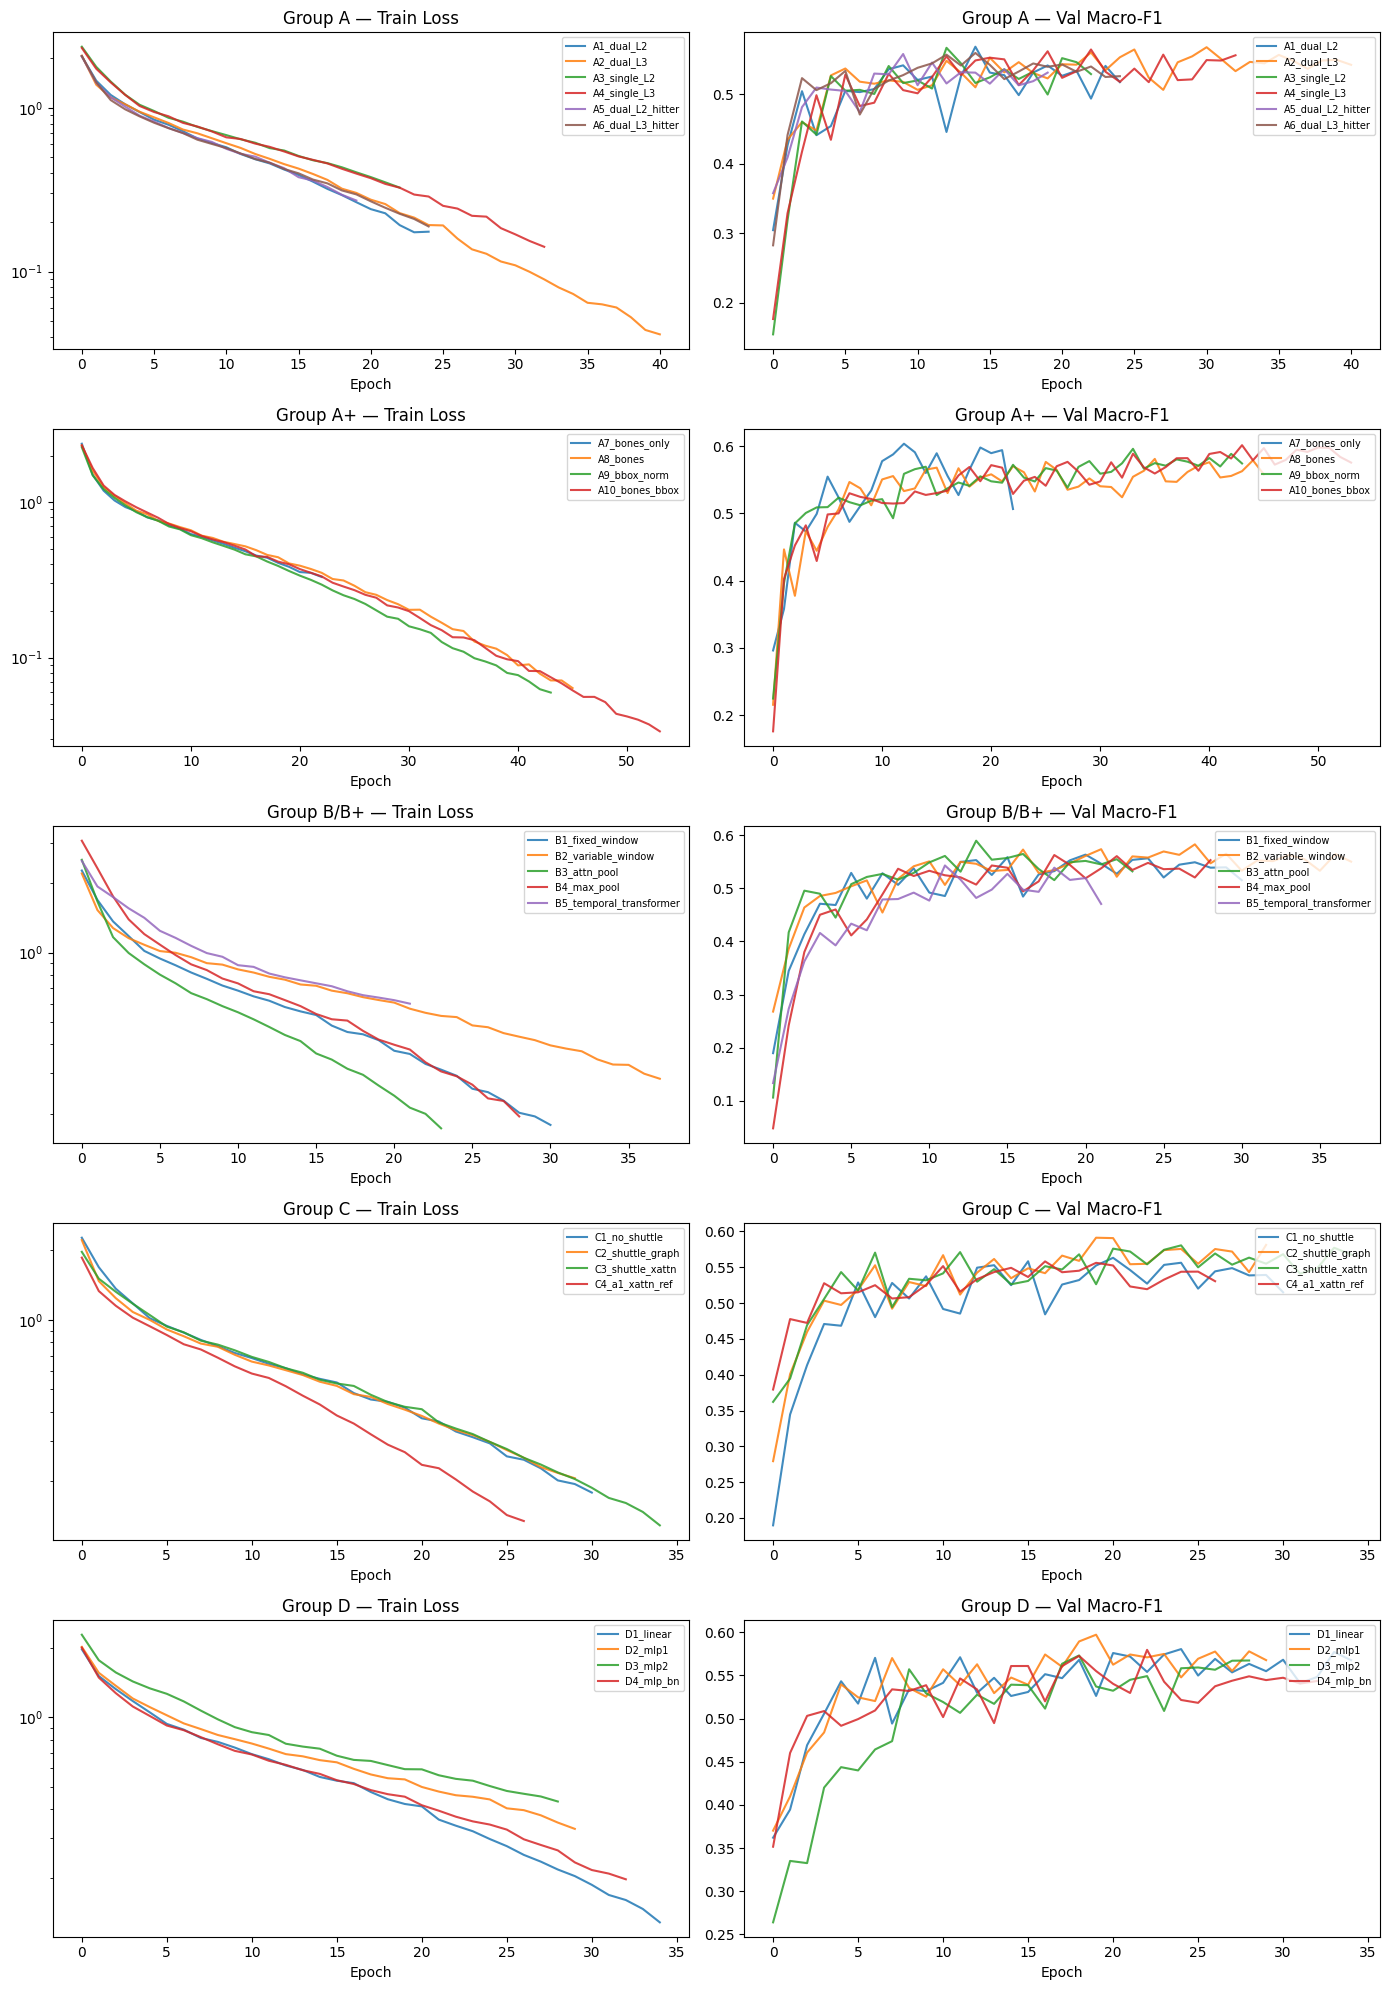

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/run6_training_curves.png


In [18]:
import matplotlib.pyplot as plt

# Training curves by group
_groups = [
    ('Group A',  ['A1_dual_L2','A2_dual_L3','A3_single_L2','A4_single_L3',
                  'A5_dual_L2_hitter','A6_dual_L3_hitter']),
    ('Group A+', ['A7_bones_only','A8_bones','A9_bbox_norm','A10_bones_bbox']),
    ('Group B/B+',['B1_fixed_window','B2_variable_window','B3_attn_pool','B4_max_pool','B5_temporal_transformer']),
    ('Group C',  ['C1_no_shuttle','C2_shuttle_graph','C3_shuttle_xattn','C4_a1_xattn_ref']),
    ('Group D',  ['D1_linear','D2_mlp1','D3_mlp2','D4_mlp_bn']),
]

fig, axes = plt.subplots(len(_groups), 2, figsize=(14, 4 * len(_groups)))
for row, (grp, names) in enumerate(_groups):
    for n in names:
        if n not in saved: continue
        r = saved[n]
        axes[row, 0].plot(r['history']['train_loss'], label=n, alpha=0.85)
        axes[row, 1].plot(r['history']['val_f1'],     label=n, alpha=0.85)
    axes[row, 0].set_title(f'{grp} — Train Loss'); axes[row, 0].set_yscale('log')
    axes[row, 1].set_title(f'{grp} — Val Macro-F1')
    for ax in axes[row]:
        ax.legend(fontsize=7, loc='upper right')
        ax.set_xlabel('Epoch')

plt.tight_layout()
out = ABLATION_DIR / 'run6_training_curves.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

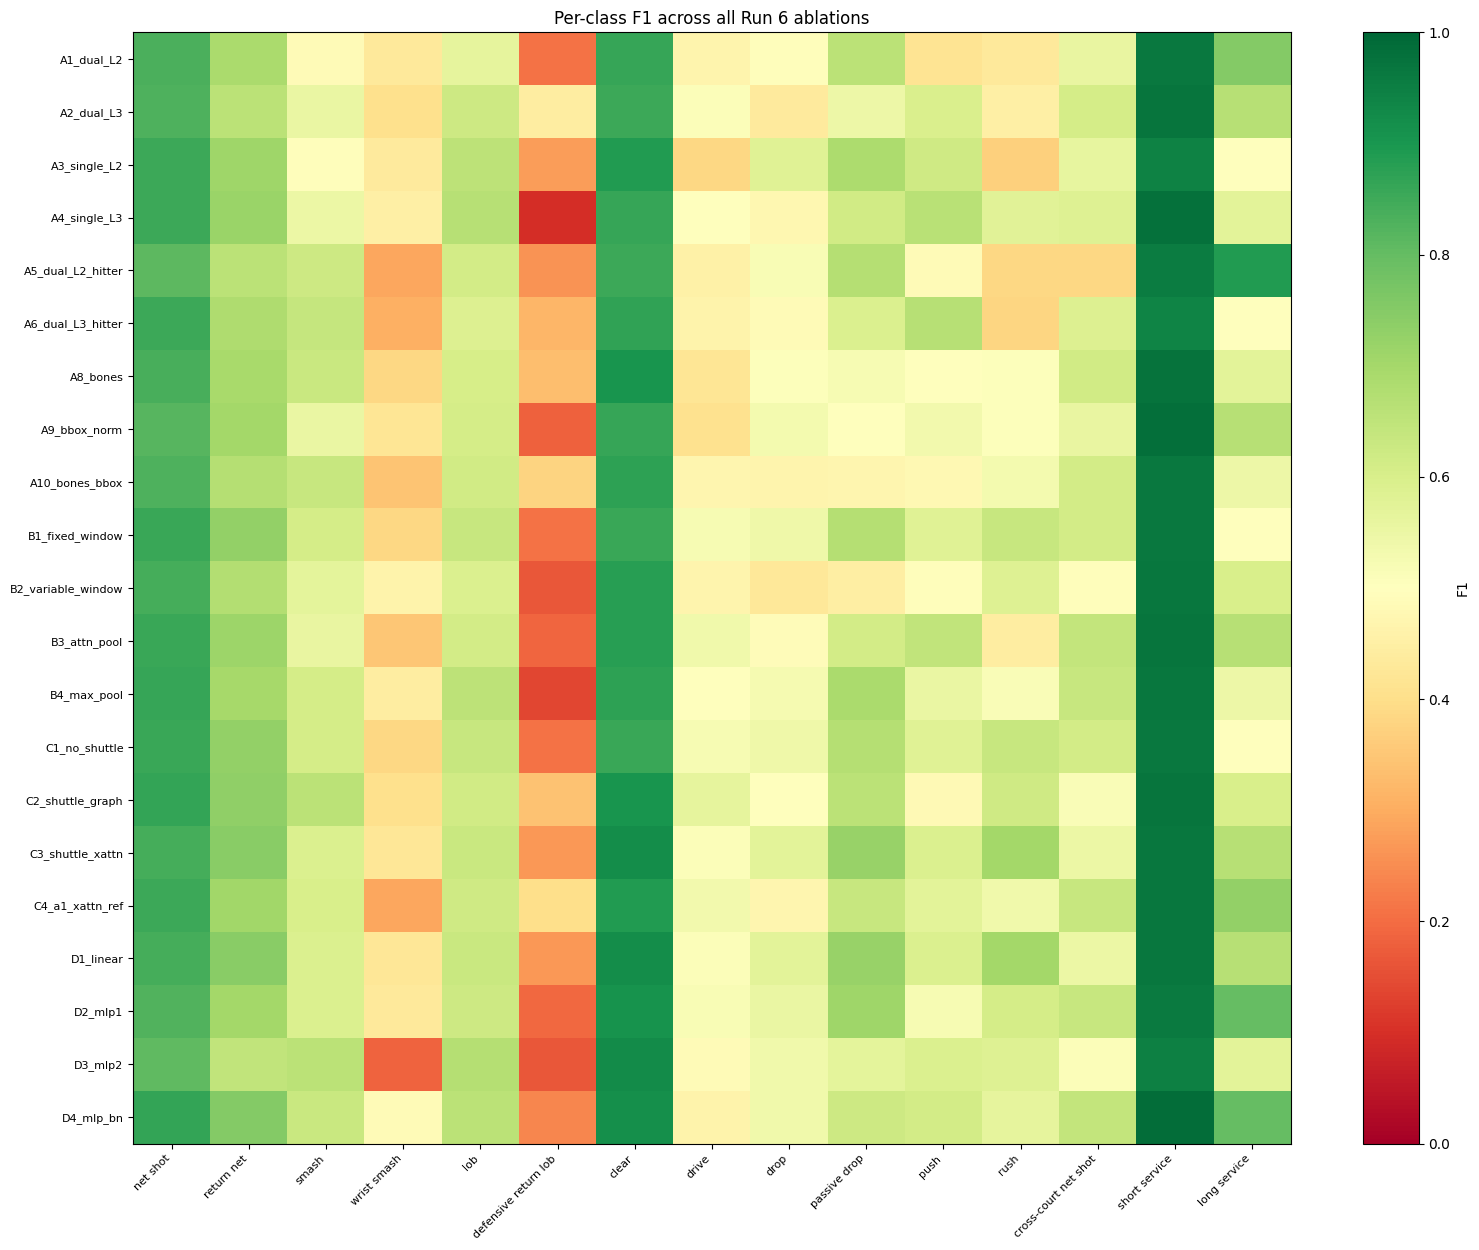

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/run6/run6_perclass_heatmap.png


In [19]:
# Per-class F1 heatmap across all completed runs
names_in_order = [n for _, ns in _order for n in ns if n in saved and n != 'B1_fixed_window' or False]
names_in_order = list(dict.fromkeys(n for _, ns in _order for n in ns if n in saved))

matrix = []
for run_name in names_in_order:
    row = []
    pc  = saved[run_name]['per_class']
    for cls in SHOT_TYPES:
        row.append(pc.get(cls, {}).get('f1-score', 0.0))
    matrix.append(row)

fig, ax = plt.subplots(figsize=(16, max(6, len(names_in_order) * 0.6)))
im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(SHOT_TYPES))); ax.set_xticklabels(SHOT_TYPES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(names_in_order))); ax.set_yticklabels(names_in_order, fontsize=8)
plt.colorbar(im, ax=ax, label='F1')
ax.set_title('Per-class F1 across all Run 6 ablations')
plt.tight_layout()
out2 = ABLATION_DIR / 'run6_perclass_heatmap.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}')

## §9 — Cross-Validation (Leave-2-Matches-Out)

CV on the 19 training-pool matches (2 held-out test matches fixed, never touched).
Each fold holds out 2 matches; remaining 17 train.

In [9]:
# ── §9 Standalone Setup ───────────────────────────────────────────────────
# No-ops if running after training cells. Run this + §9 from a fresh kernel.
from pathlib import Path
from collections import Counter
import numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset as _DS

try:
    _ = ABLATION_DIR
except NameError:
    from src.config import (
        FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER, BONE_CHANNELS,
        SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
        SHOT_TYPES, NUM_SHOT_TYPES, NUM_NODES, NUM_JOINTS, MODELS_DIR, RESULTS_DIR,
    )
    ABLATION_DIR  = RESULTS_DIR / 'ablations' / 'run6'
    MODELS_DIR_R6 = MODELS_DIR  / 'run6'
    N_CLASSES     = NUM_SHOT_TYPES
    device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SHOT_WINDOW   = 32
    EPOCHS = 80; BATCH_SIZE = 64; LR = 1e-3; WEIGHT_DECAY = 1e-4; PATIENCE = 10; SEED = 42

try:
    _skel = local_skel; _shutt = local_shutt
except NameError:
    from src.config import SS_SKELETONS_GDINO, SS_SHUTTLES
    _skel = SS_SKELETONS_GDINO; _shutt = SS_SHUTTLES

try:
    evaluate
except NameError:
    from src.data.graph_builder import GraphBuilder
    from src.data.dataset import ShuttleSetDataset
    from src.models.stgcn_model import STGCN
    from src.models.shuttle_cross_attn import ShuttleCrossAttention
    from sklearn.metrics import f1_score, accuracy_score

    class SinglePlayerWrapper(_DS):
        def __init__(self, ds): self.ds = ds; self.samples = ds.samples
        def __len__(self): return len(self.ds)
        def __getitem__(self, idx):
            item = self.ds[idx]; x, label = item[0], item[1]
            info = self.ds.samples[idx]
            hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
            x = x[:, :, NUM_JOINTS:] if hitter == 'bottom' else x[:, :, :NUM_JOINTS]
            return x, label

    def collate_fn(batch):
        xs, labels = zip(*[(b[0], b[1]) for b in batch])
        return torch.stack(xs), torch.tensor(labels, dtype=torch.long)

    def collate_fn_shuttle(batch):
        xs, labels, shuttles = [], [], []
        for item in batch:
            xs.append(item[0]); labels.append(item[1])
            shuttles.append(item[2] if len(item) == 3 else torch.zeros(2, SHOT_WINDOW))
        return torch.stack(xs), torch.tensor(labels, dtype=torch.long), torch.stack(shuttles)

    def compute_class_weights(dataset):
        labels  = [s.get('shot_type_idx') for s in dataset.samples
                   if s.get('shot_type_idx') is not None]
        counts  = Counter(labels); total = sum(counts.values())
        weights = torch.ones(N_CLASSES, dtype=torch.float32)
        for cls_id, cnt in counts.items():
            if cls_id < N_CLASSES: weights[cls_id] = total / (len(counts) * cnt)
        return weights

    def build_encoder(in_channels, num_nodes=NUM_NODES, pooling='mean'):
        single = (num_nodes == NUM_JOINTS)
        adj = GraphBuilder(use_inter_player=not single,
                           single_player=single).build_adjacency().to(device)
        return STGCN(in_channels=in_channels, num_nodes=num_nodes, adjacency=adj,
                     num_layers=9, base_channels=64, embedding_dim=256,
                     temporal_kernel=9, dropout=0.3, pooling=pooling).to(device)

    def evaluate(encoder, head, ds, cross_attn=None):
        cfn    = collate_fn_shuttle if cross_attn else collate_fn
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=0, collate_fn=cfn)
        encoder.eval(); head.eval()
        if cross_attn: cross_attn.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                xb, yb = batch[0], batch[1]; valid = yb >= 0
                if not valid.any(): continue
                emb = encoder(xb[valid].to(device))
                if cross_attn: emb = cross_attn(emb, batch[2][valid].to(device))
                all_logits.append(head(emb).cpu()); all_labels.append(yb[valid])
        if not all_logits: return 0.0, 0.0, np.array([]), np.array([]), {}
        logits = torch.cat(all_logits); y_true = torch.cat(all_labels).numpy()
        y_pred = logits.argmax(1).numpy()
        topk = {f'top{k}_acc': logits.topk(k,1).indices.eq(
                    torch.tensor(y_true).unsqueeze(1)).any(1).float().mean().item()
                for k in [3, 5] if logits.shape[1] >= k}
        return (f1_score(y_true, y_pred, average='macro', zero_division=0),
                accuracy_score(y_true, y_pred), y_true, y_pred, topk)

    print('Standalone helpers defined.')

print(f'Ready. Device={device}  ABLATION_DIR={ABLATION_DIR}')

Ready. Device=cuda  ABLATION_DIR=/content/drive/MyDrive/Baddiev2/results/ablations/run6


In [11]:
# ══════════════════════════════════════════════════════════════════════════
# §9 — Cross-Validation (Leave-2-Matches-Out)
# ══════════════════════════════════════════════════════════════════════════
CV_MODE = 'winner_only'   # 'winner_only' | 'A_group' | 'Aplus_group'

import json as _json, time, numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader

try:
    _ = ABLATION_DIR
except NameError:
    from src.config import (
        BONE_CHANNELS, FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER,
        SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
        SHOT_TYPES, NUM_SHOT_TYPES, NUM_NODES, NUM_JOINTS, MODELS_DIR, RESULTS_DIR,
    )
    from src.data.dataset import ShuttleSetDataset
    from src.models.stgcn_model import STGCN
    from src.models.shuttle_cross_attn import ShuttleCrossAttention
    ABLATION_DIR  = RESULTS_DIR / 'ablations' / 'run6'
    MODELS_DIR_R6 = MODELS_DIR  / 'run6'
    N_CLASSES = NUM_SHOT_TYPES
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    EPOCHS=80; BATCH_SIZE=64; LR=1e-3; WEIGHT_DECAY=1e-4; PATIENCE=10; SEED=42

try:
    _skel = local_skel;  _shutt = local_shutt
except NameError:
    _skel = SS_SKELETONS_GDINO;  _shutt = SS_SHUTTLES

# ── Load final config (fallback to cascade vars if file not yet written) ────
_cfg_path = ABLATION_DIR / '_final_config.json'
if _cfg_path.exists():
    with open(_cfg_path) as _f:
        _fc = _json.load(_f)
else:
    _use_shuttle_ca = 'C3' in best_c['name'] or 'cross' in best_c['name']
    _use_shuttle_g  = 'C2' in best_c['name']
    _fc = dict(
        winner_name    = best_c['name'],
        feature_layer  = _a_feat,
        single_player  = _a_single,
        use_hitter     = _a_hitter,
        use_bones      = _use_bones,
        use_bbox_norm  = _use_bbox,
        variable_window= _variable_win,
        pooling        = _pooling,
        use_shuttle    = _use_shuttle_ca or _use_shuttle_g,
        shuttle_fusion = 'cross_attn' if _use_shuttle_ca else ('graph' if _use_shuttle_g else 'none'),
        in_channels    = _aplus_in_ch,
        num_nodes      = _a_nodes,
    )
    print('Note: _final_config.json not found — using in-memory cascade variables.')

# ── Build CV folds ────────────────────────────────────────────────────────
with open(SS_SPLIT_JSON) as _f:
    _sp = _json.load(_f)
_pool = sorted(_sp['train'])   # 19 matches
_held = set(_sp['held_out'])   # 2 fixed, never used in CV
_rng2 = np.random.RandomState(SEED)
_shuf = list(_pool); _rng2.shuffle(_shuf)
CV_FOLDS = [(set(_shuf[i:i+2]), set(_pool) - set(_shuf[i:i+2]))
            for i in range(0, len(_shuf), 2)]
print(f'CV_MODE={CV_MODE}  |  {len(CV_FOLDS)} folds  |  {len(_pool)} train-pool matches')

# ── CV training function ───────────────────────────────────────────────────
def _cv_train(name, tr_m, va_m, build_fn):
    tr_ds, va_ds, enc, hd, ca = build_fn(tr_m, va_m)
    cfn = collate_fn_shuttle if ca else collate_fn
    loader   = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True, collate_fn=cfn)
    cw       = compute_class_weights(tr_ds).to(device)
    crit     = nn.CrossEntropyLoss(weight=cw)
    params   = list(enc.parameters()) + list(hd.parameters())
    if ca: params += list(ca.parameters())
    opt      = optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    sched    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    best_f1  = -1.0; no_imp = 0
    for ep in range(EPOCHS):
        enc.train(); hd.train()
        if ca: ca.train()
        for batch in loader:
            xb, yb = batch[0], batch[1]; valid = yb >= 0
            if not valid.any(): continue
            emb = enc(xb[valid].to(device))
            if ca: emb = ca(emb, batch[2][valid].to(device))
            loss = crit(hd(emb), yb[valid].to(device))
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        sched.step()
        f1, *_ = evaluate(enc, hd, va_ds, ca)
        if f1 > best_f1 + 1e-4: best_f1 = f1; no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE: break
    return best_f1

# ── Builder functions ─────────────────────────────────────────────────────
def _mk_ds(m, **kw):
    ds = ShuttleSetDataset(skeleton_dir=_skel, shot_window=32, load_shot_types=True, split=None,
                           shuttle_dir=_shutt if kw.get('use_shuttle') else None, **kw)
    ds.samples = [s for s in ds.samples
                  if isinstance(s, dict) and Path(s.get('skel_dir','')).name in m]
    return ds

def _build(feat, single, hitter, bones=False, bbox=False, pooling='mean',
           var_win=False, shuttle=False, fusion='none'):
    def fn(tr_m, va_m):
        kw = dict(feature_layer=feat, use_hitter=hitter, use_bones=bones,
                  use_bbox_norm=bbox, variable_window=var_win,
                  use_shuttle=shuttle, shuttle_fusion=fusion)
        tr = _mk_ds(tr_m, **kw); va = _mk_ds(va_m, **kw)
        if single: tr = SinglePlayerWrapper(tr); va = SinglePlayerWrapper(va)
        in_ch = (FEATURE_DIMS_WITH_HITTER if hitter else FEATURE_DIMS)[feat]
        in_ch += BONE_CHANNELS if bones else 0
        n_nodes = NUM_JOINTS if single else NUM_NODES
        enc = build_encoder(in_ch, num_nodes=n_nodes, pooling=pooling)
        hd  = nn.Linear(256, N_CLASSES).to(device)
        ca  = None
        if shuttle and fusion == 'cross_attn':
            from src.models.shuttle_cross_attn import ShuttleCrossAttention
            ca = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
        return tr, va, enc, hd, ca
    return fn

# ── Assemble configs per mode ─────────────────────────────────────────────
if CV_MODE == 'winner_only':
    _cv_configs = {_fc['winner_name']: _build(
        _fc['feature_layer'], _fc['single_player'], _fc['use_hitter'],
        bones=_fc['use_bones'], bbox=_fc['use_bbox_norm'], pooling=_fc['pooling'],
        var_win=_fc['variable_window'], shuttle=_fc['use_shuttle'],
        fusion=_fc['shuttle_fusion'] if _fc['use_shuttle'] else 'none',
    )}
elif CV_MODE == 'A_group':
    _cv_configs = {
        'A1_dual_L2':         _build('L2', False, False),
        'A2_dual_L3':         _build('L3', False, False),
        'A3_single_L2':       _build('L2', True,  False),
        'A4_single_L3':       _build('L3', True,  False),
        'A5_dual_L2_hitter':  _build('L2', False, True),
        'A6_dual_L3_hitter':  _build('L3', False, True),
    }
else:   # Aplus_group
    _cv_configs = {
        'A1_baseline':    _build('L2', False, False),
        'A7_bones_only':  _build('L0', False, False, bones=True),
        'A8_bones':       _build('L2', False, False, bones=True),
        'A9_bbox_norm':   _build('L2', False, False, bbox=True),
        'A10_bones_bbox': _build('L2', False, False, bones=True, bbox=True),
    }

# ── Run CV ────────────────────────────────────────────────────────────────
from collections import defaultdict
cv_res = defaultdict(list)
t0 = time.time()
for fi, (va_m, tr_m) in enumerate(CV_FOLDS):
    print(f'\nFold {fi+1}/{len(CV_FOLDS)} — val: {sorted(va_m)}')
    for nm, builder in _cv_configs.items():
        torch.manual_seed(SEED + fi)
        f1 = _cv_train(nm, tr_m, va_m, builder)
        cv_res[nm].append(f1)
        print(f'  {nm}: {f1:.4f}')

elapsed = time.time() - t0
print(f'\nCV done in {elapsed/60:.1f} min')
print(f'\n{"Ablation":<30} {"Mean F1":>10} {"± Std":>10} {"Min":>8} {"Max":>8}')
print('-' * 70)
for nm, scores in sorted(cv_res.items(), key=lambda x: -np.mean(x[1])):
    print(f'{nm:<30} {np.mean(scores):>10.4f} {np.std(scores):>10.4f} '
          f'{min(scores):>8.4f} {max(scores):>8.4f}')

_cv_save = {nm: {'scores': [round(s,4) for s in sc],
                 'mean': round(float(np.mean(sc)),4),
                 'std':  round(float(np.std(sc)),4)}
            for nm, sc in cv_res.items()}
_cv_save['_meta'] = {'cv_mode': CV_MODE, 'n_folds': len(CV_FOLDS),
                     'folds': [{'val': sorted(v), 'train_size': len(t)} for v,t in CV_FOLDS],
                     'elapsed_min': round(elapsed/60, 1)}
with open(ABLATION_DIR / '_cv_results.json', 'w') as _f:
    _json.dump(_cv_save, _f, indent=2)
print(f'Saved: {ABLATION_DIR}/_cv_results.json')

CV_MODE=winner_only  |  10 folds  |  19 train-pool matches

Fold 1/10 — val: ['Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals', 'CHOU_Tien_Chen_Jonatan_CHRISTIE_Indonesia_Open_2019_Quarter-finals']
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  C3_shuttle_xattn: 0.5961

Fold 2/10 — val: ['Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals', 'Viktor_AXELSEN _SHI_Yu_Qi_All_England_Open_2020_QuarterFinals']
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
[INFO] ShuttleSet split='None': 19470 shots from whole-match skeletons across 21 match(es)
  C3_shuttle_xattn: 0.6365

Fold 3/10 — val: ['NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals', 'Viktor_Axelsen_Jonatan_Christie_YONEX_Thailand_Open_2021_QuarterFinals']
[INFO] ShuttleSet split='None': 19470 s